# Experiment 1 — headline benchmark (PD)

5-fold CV on the PD datasets (tuned/HPO models). For every matrix metric — **AUC**, **Brier**, **F1** — the **same three views**: dataset×method **matrix** (best column left), per-method **bar** (value above; fold-level std error bars), and a **box** plot of the across-dataset spread. The **rank by AUC** (kept right after AUC) gets the same three views. Then the **effect of HPO**, a **time analysis** (train + predict + HPO), a **prediction-calibration analysis**, and a summary table. Foundation-model names are **red**. Figures → `figures/experiment1/pd/`.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.paths import results_root
from src.methods.method_config import HPO_METHODS          # tuned methods -> HPO time x n_trials
from src.visualizations.experiment_plots import (
    apply_style, reset_figure_dir, load_summary,
    performance_heatmap, metric_bars, metric_boxplots,
    rank_heatmap, method_ranking_bars, rank_boxplots,
    hpo_improvement_bars, compute_time_bars, compute_time_boxplot,
    runtime_performance_scatter, foundation_vs_baseline_size_trend,
    foundation_vs_baseline_scatter, foundation_vs_baseline_imbalance_trend,
    calibration_bias_table, selected_method_calibration_summary,
    calibration_decile_curve, per_dataset_calibration_grid,
    per_dataset_prediction_density,
    pd_summary_text, lgd_summary_text, calibration_summary_text,
    rank_summary_text, hpo_effect_text, head_to_head_text,
)
from src.utils.report import notebook_report, capture, section
apply_style()

RESULTS_ROOT = results_root()          # override here if your copy lives elsewhere
SUMMARY_DIR  = RESULTS_ROOT / 'summaries'
FIGURES_DIR  = reset_figure_dir(PROJECT_ROOT / 'figures' / 'experiment1/pd')


In [2]:
df      = load_summary(SUMMARY_DIR, experiment='experiment1', task='pd', aggregated=False, hpo_mode='HPO')   # tuned models + their times
df_both = load_summary(SUMMARY_DIR, experiment='experiment1', task='pd', aggregated=False, hpo_mode=None)    # HPO vs NO_HPO, for the HPO-effect bars


[CONFIG_NOTEBOOKS.yaml] excluded from this analysis: tabfm
[CONFIG_NOTEBOOKS.yaml] excluded from this analysis: tabfm


## 1. AUC — discrimination

Matrix · per-method bar (fold-level std) · across-dataset box.

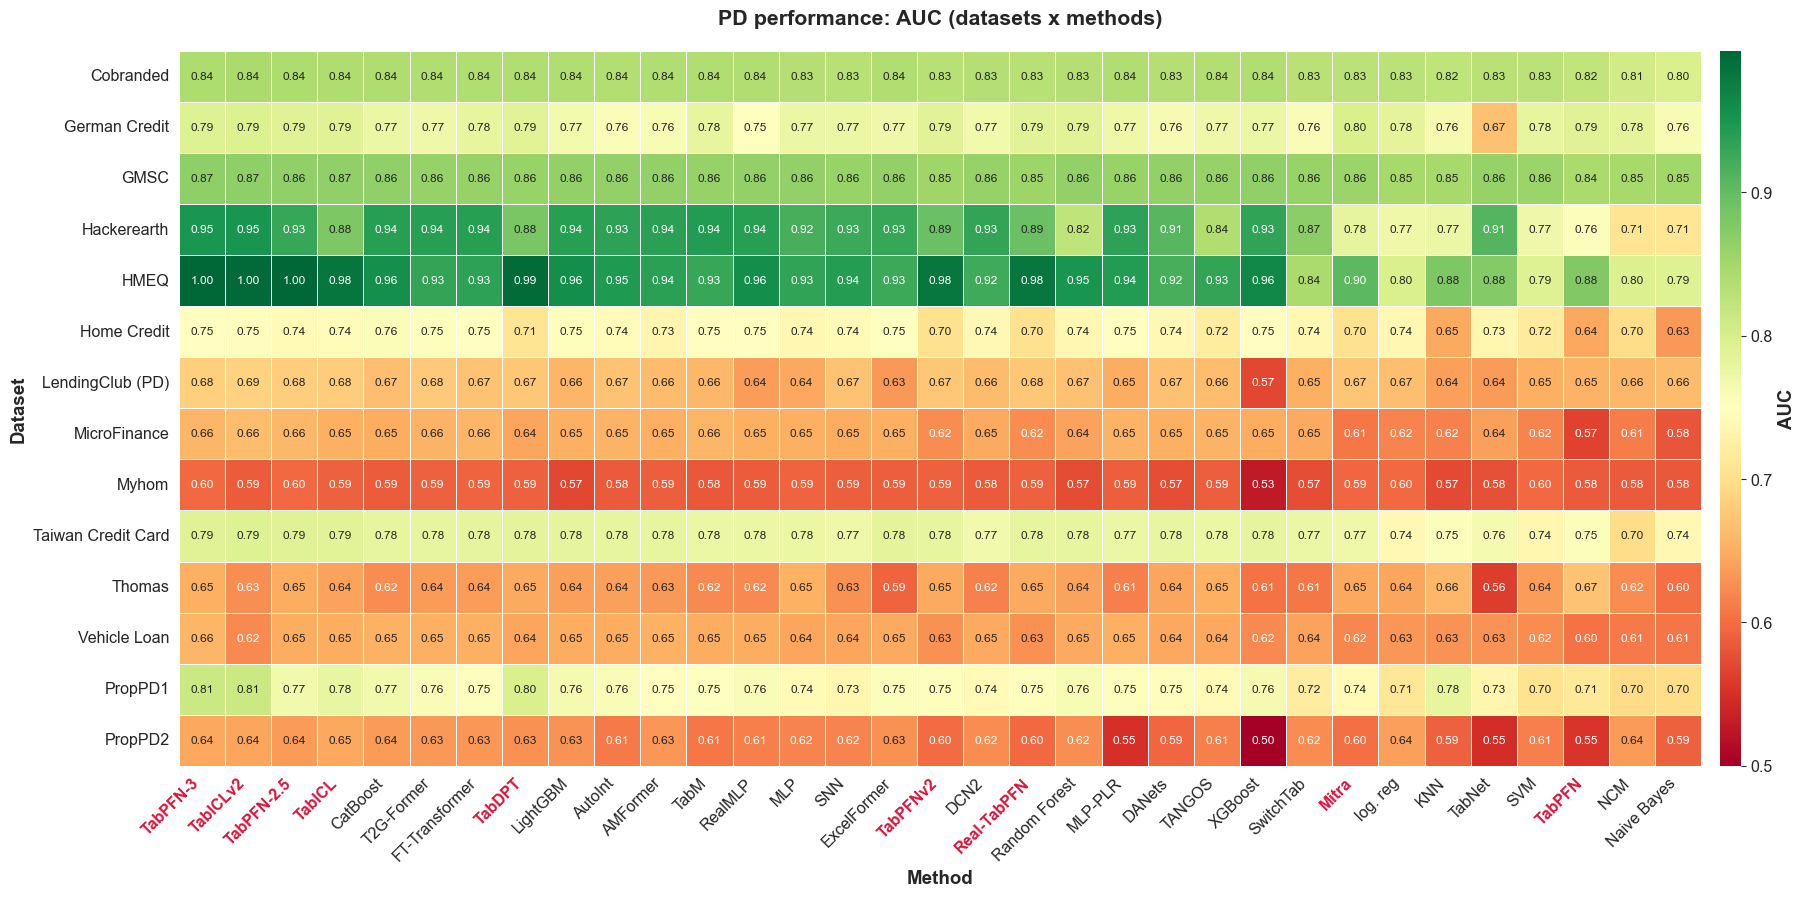

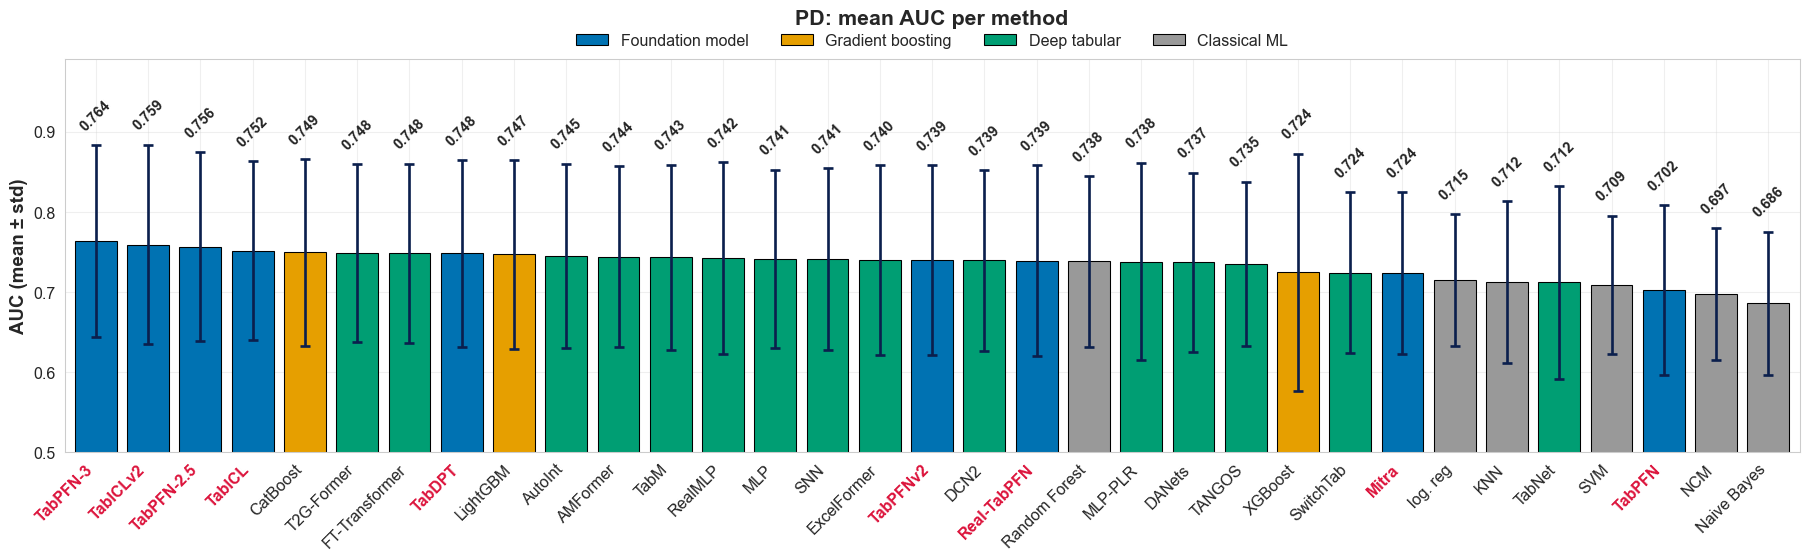

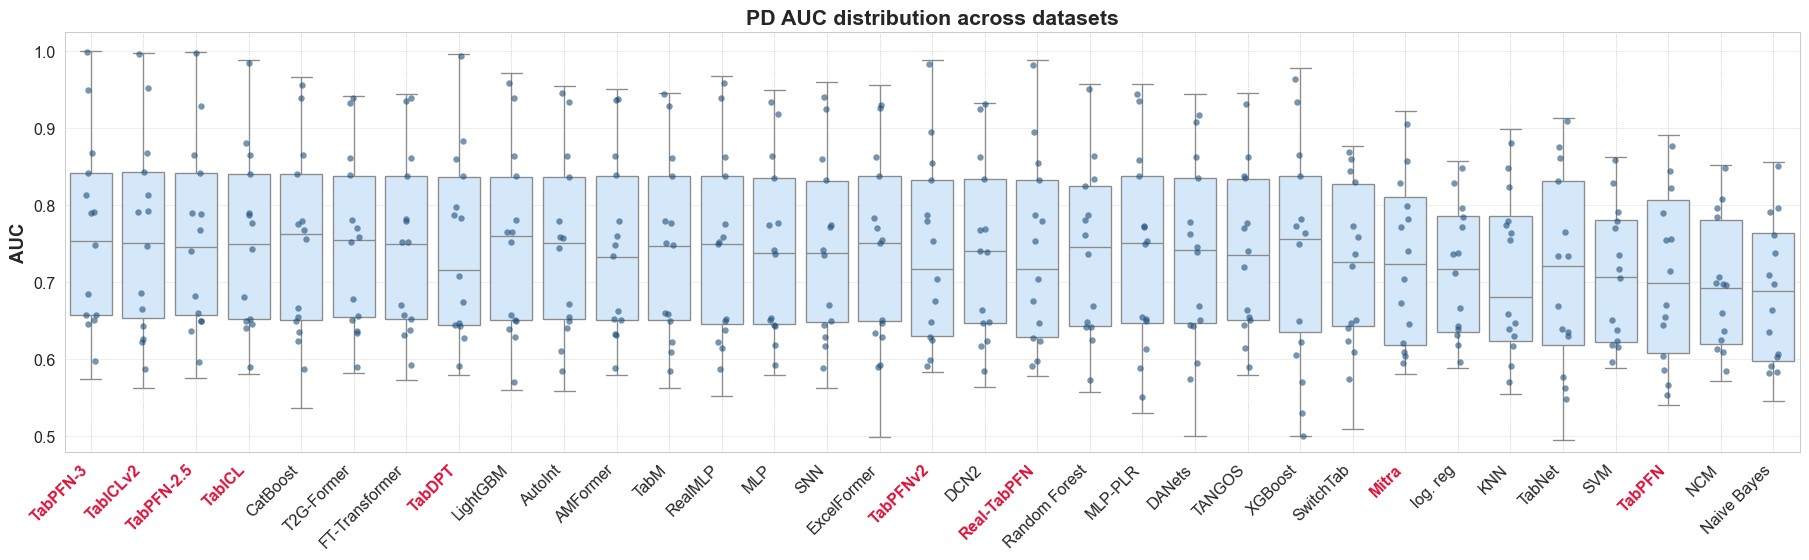

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/pd/pd_box_auc.pdf')

In [3]:
performance_heatmap(df, 'AUC', task_name='PD', higher_is_better=True, out_dir=FIGURES_DIR)
metric_bars(df, 'AUC', task_name='PD', higher_is_better=True, out_dir=FIGURES_DIR)
metric_boxplots(df, 'AUC', task_name='PD', higher_is_better=True, out_dir=FIGURES_DIR)


## 2. Rank by AUC (1 = best on that dataset)

The per-dataset ranking that underlies the AUC table — kept right next to it. Matrix · mean-rank bar · rank box.

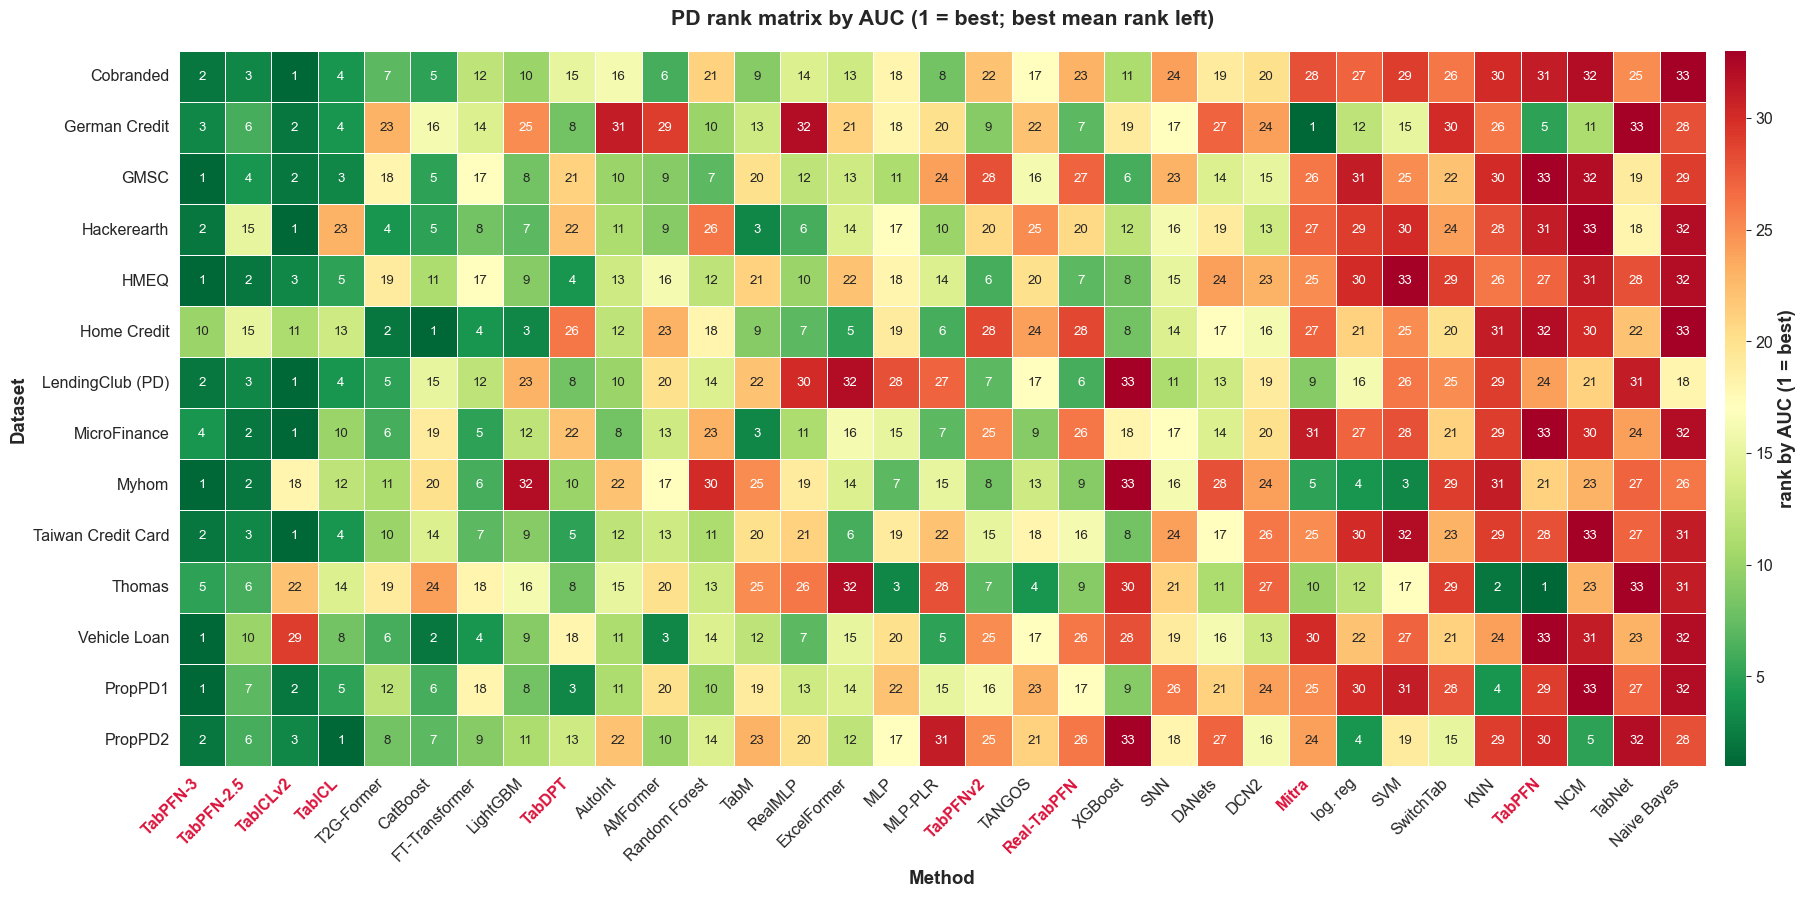

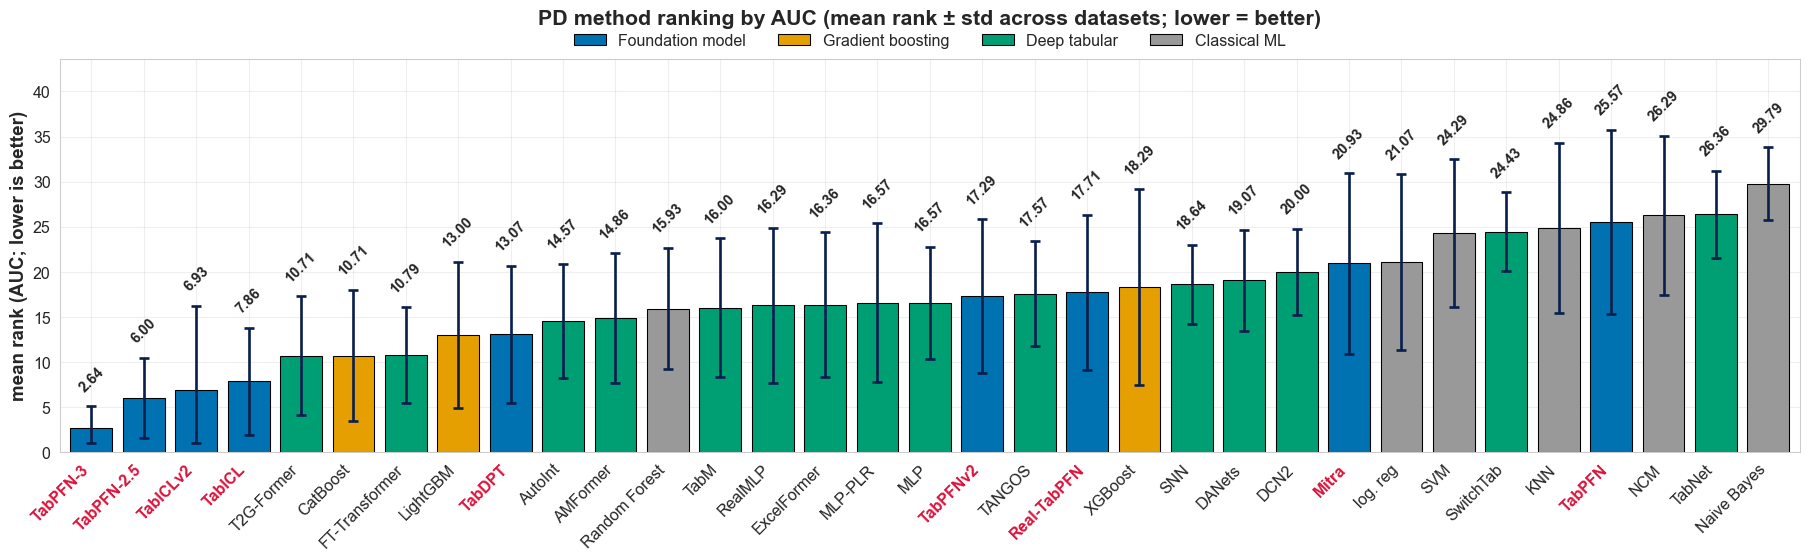

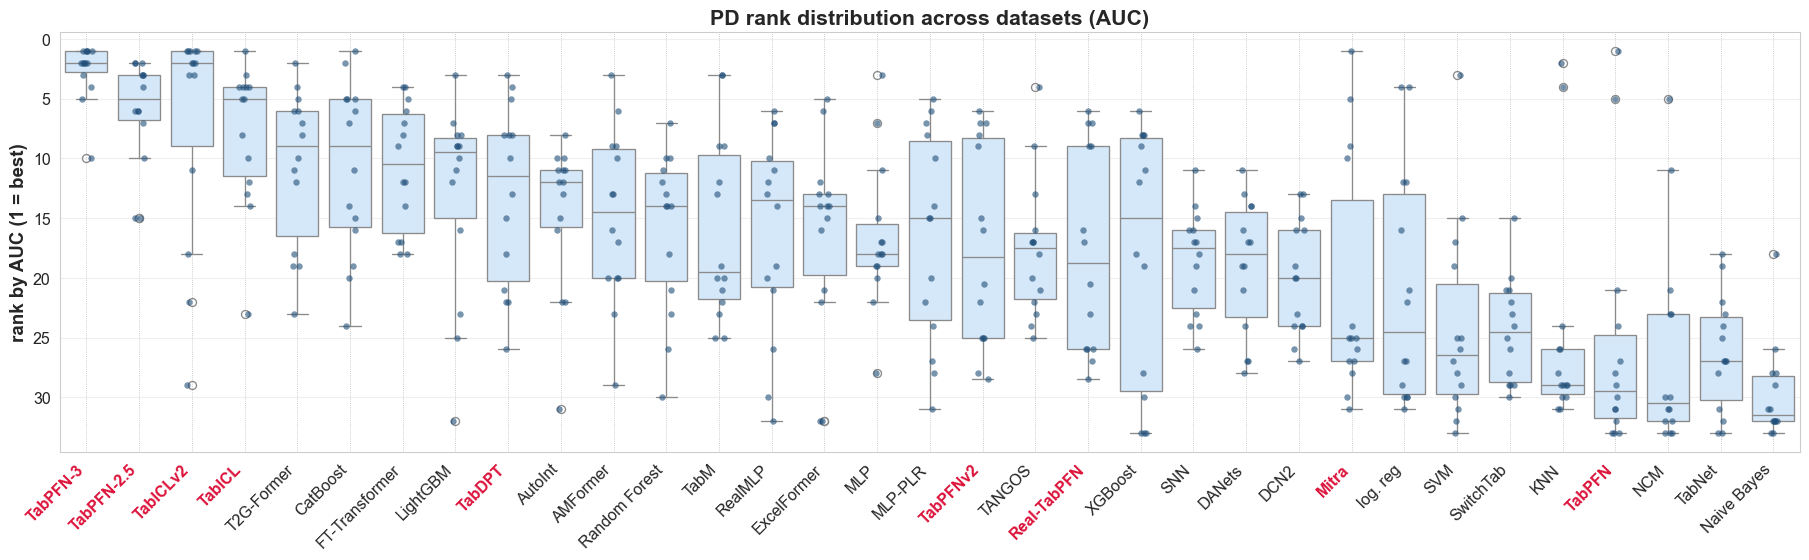

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/pd/pd_rank_box_auc.pdf')

In [4]:
rank_heatmap(df, 'AUC', task_name='PD', out_dir=FIGURES_DIR)
method_ranking_bars(df, 'AUC', task_name='PD', out_dir=FIGURES_DIR)
rank_boxplots(df, 'AUC', task_name='PD', out_dir=FIGURES_DIR)


## 3. Brier score — calibration (lower is better)

Matrix · bar · box.

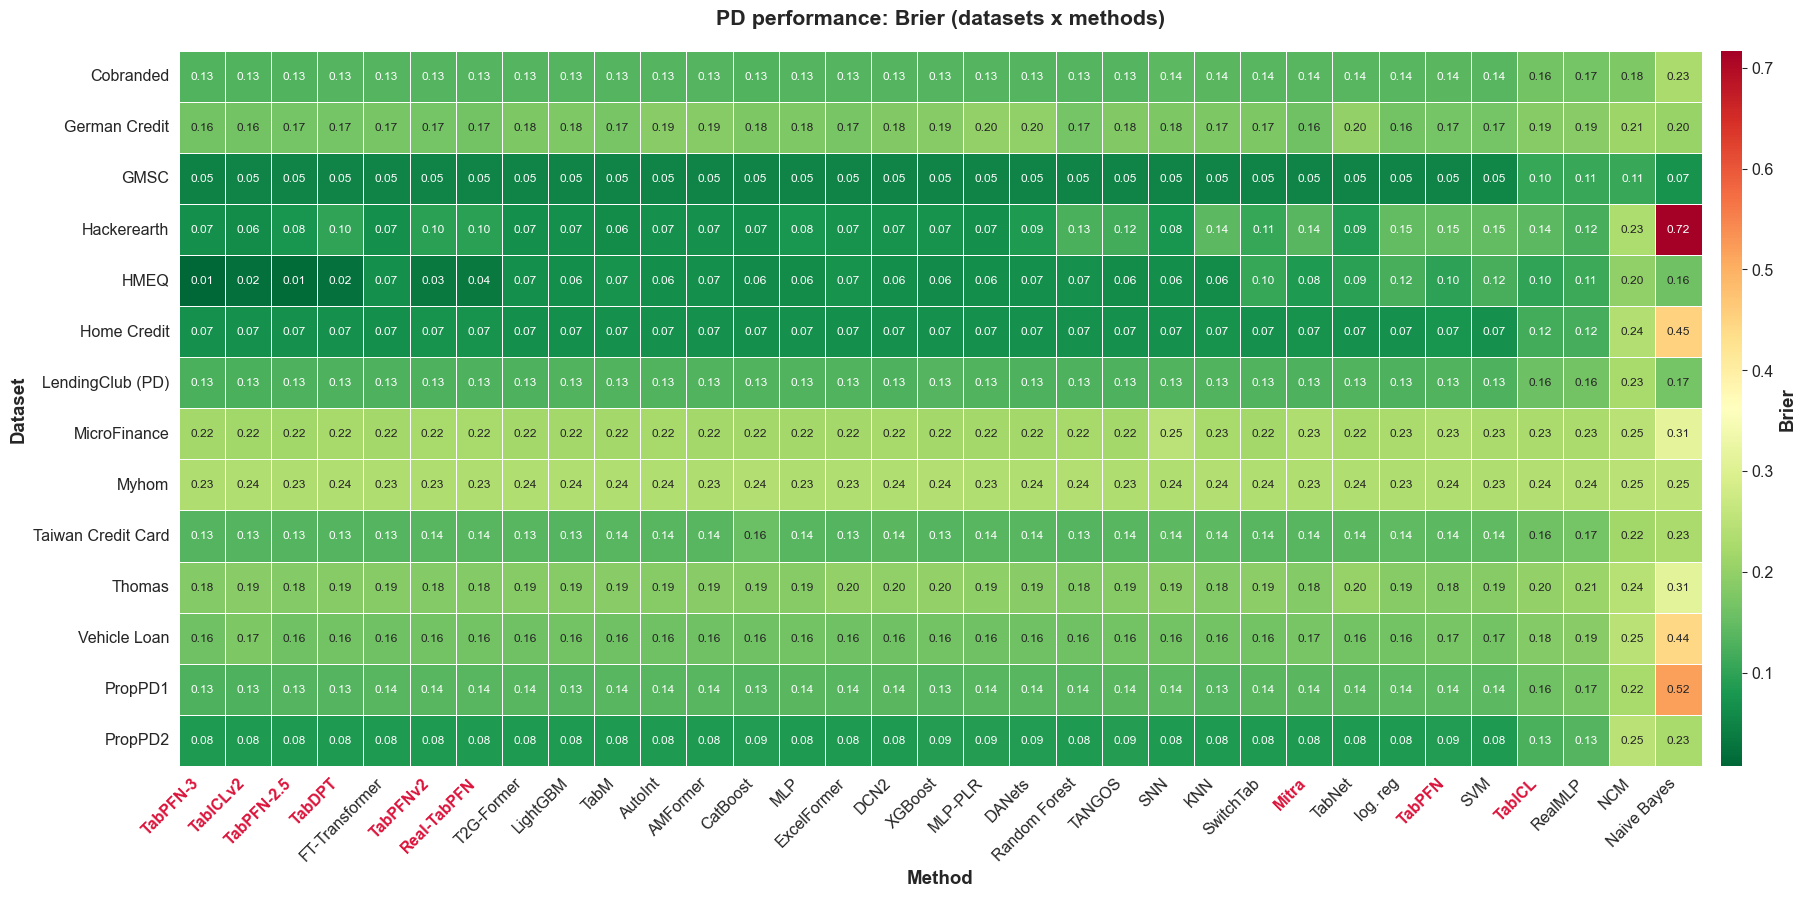

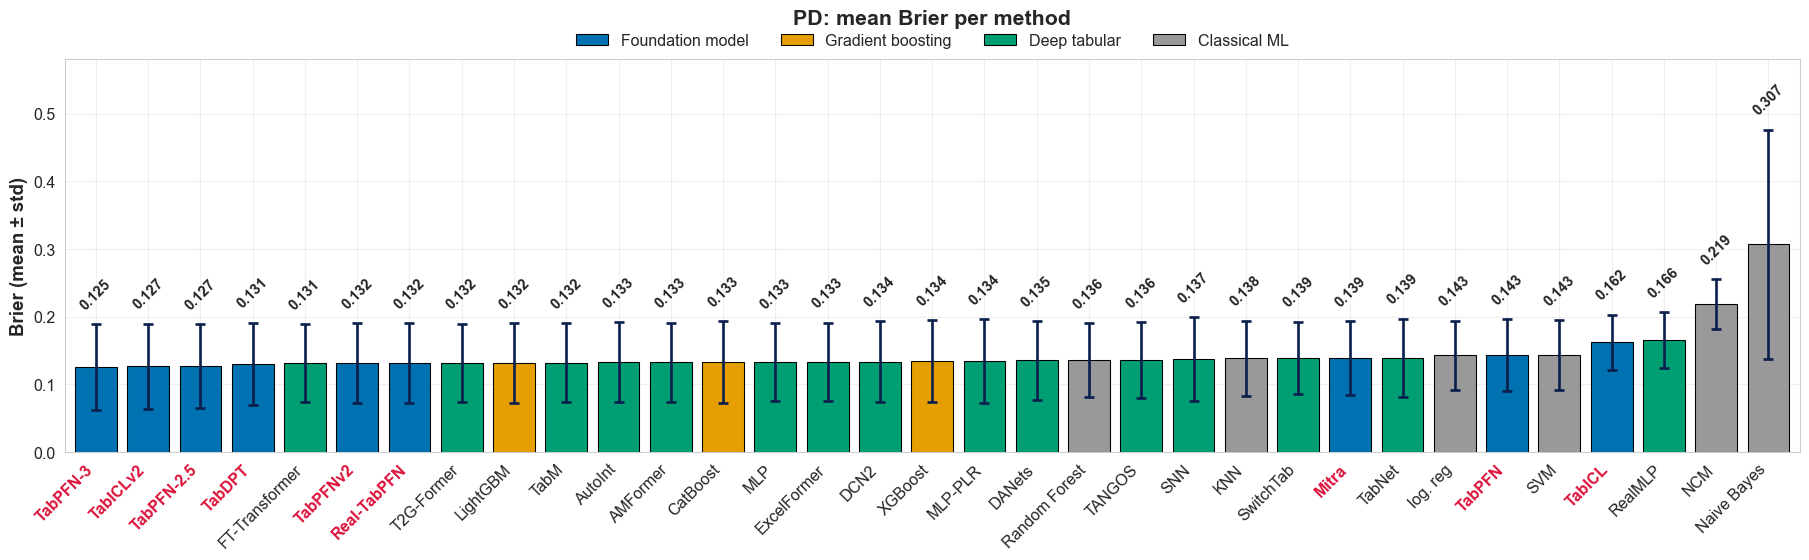

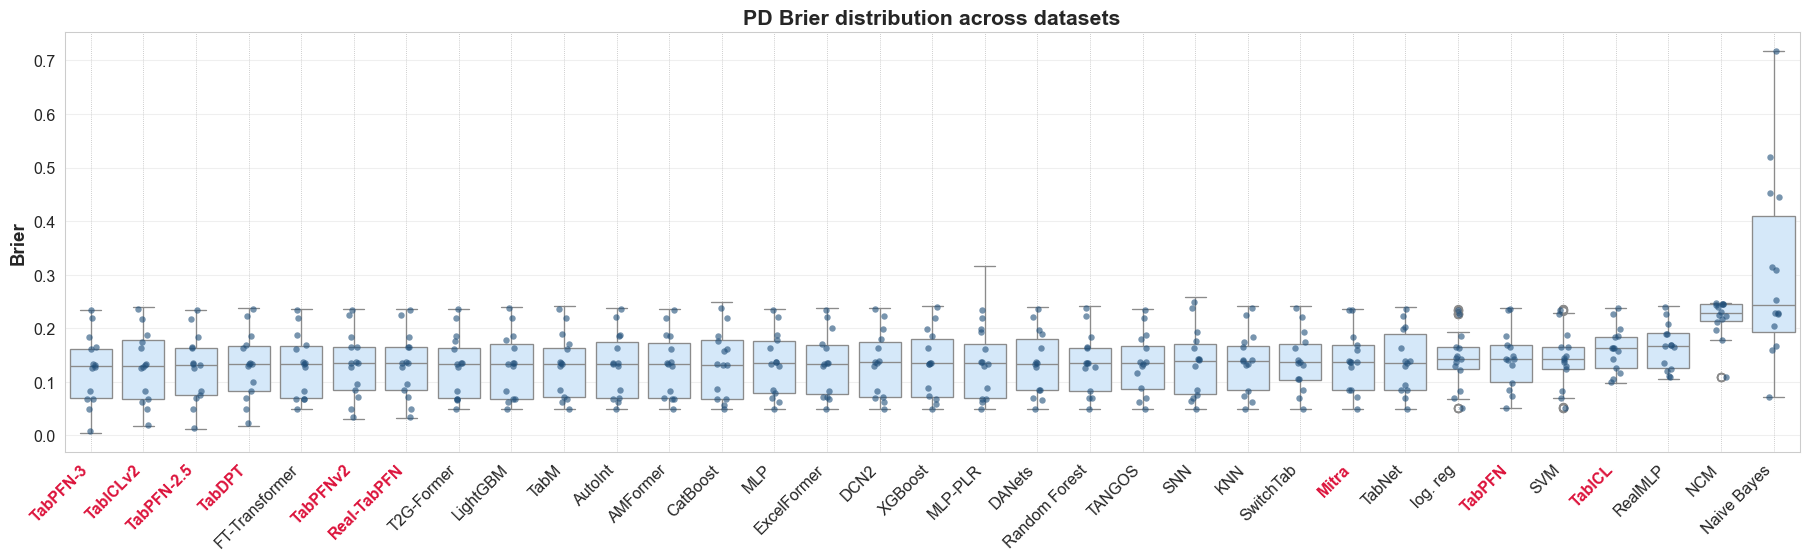

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/pd/pd_box_brier.pdf')

In [5]:
performance_heatmap(df, 'Brier', task_name='PD', higher_is_better=False, out_dir=FIGURES_DIR)
metric_bars(df, 'Brier', task_name='PD', higher_is_better=False, out_dir=FIGURES_DIR)
metric_boxplots(df, 'Brier', task_name='PD', higher_is_better=False, out_dir=FIGURES_DIR)


## 4. F1 — decision quality

Matrix · bar · box.

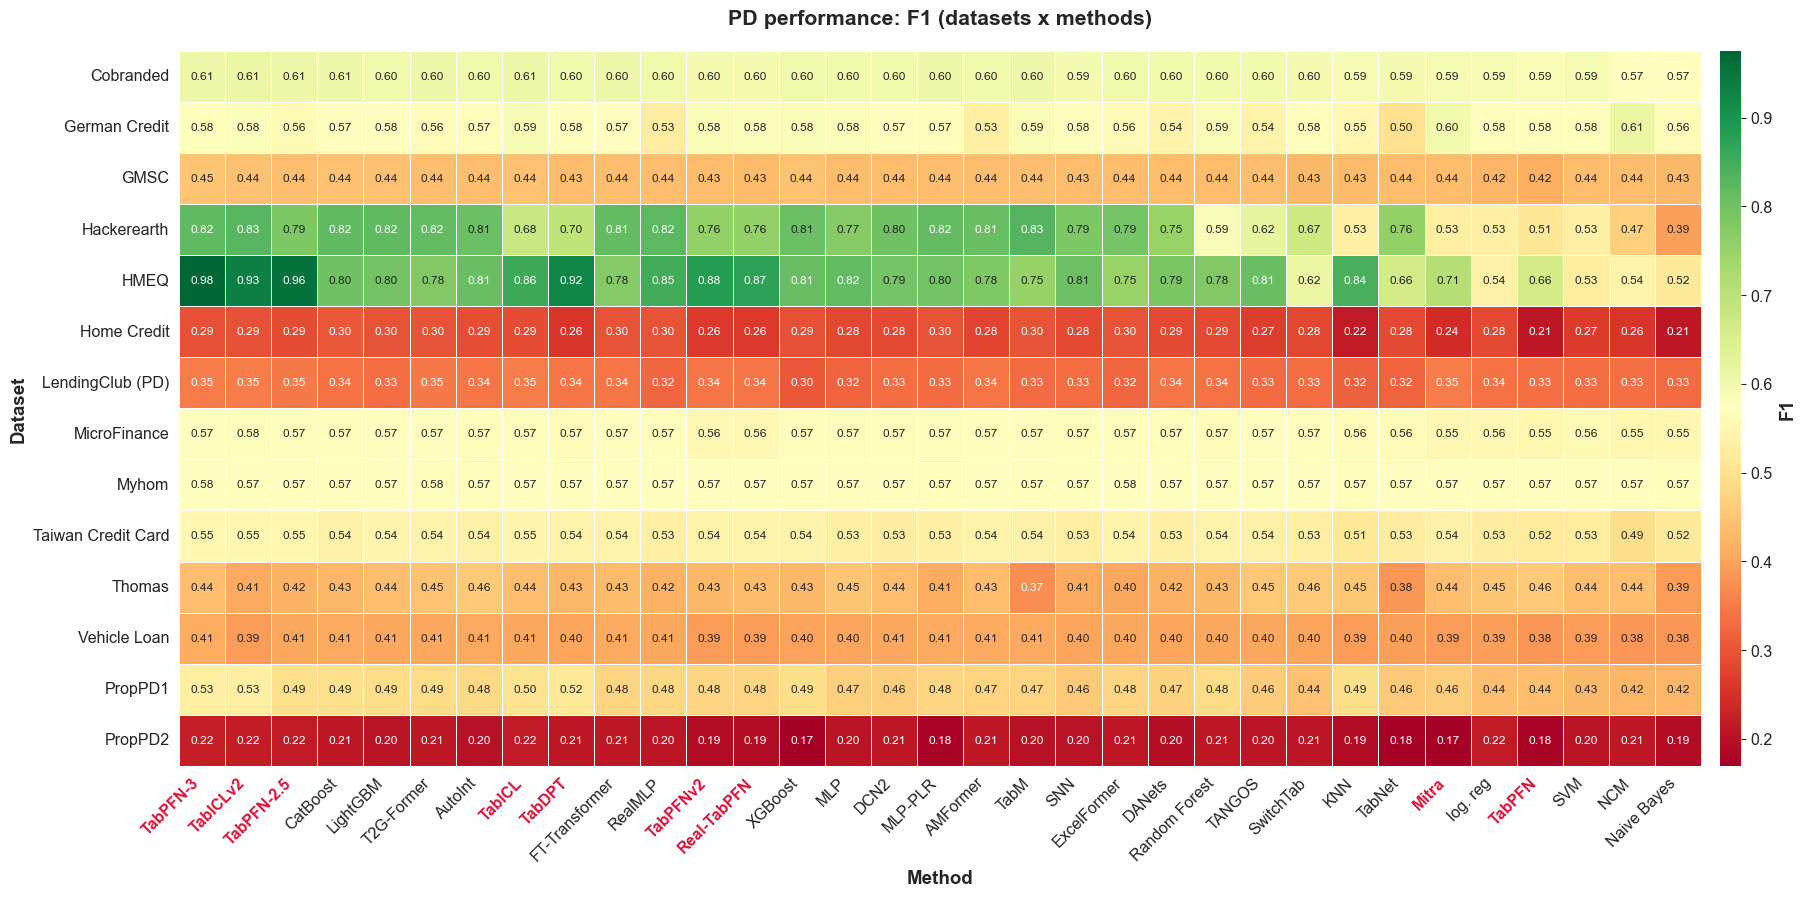

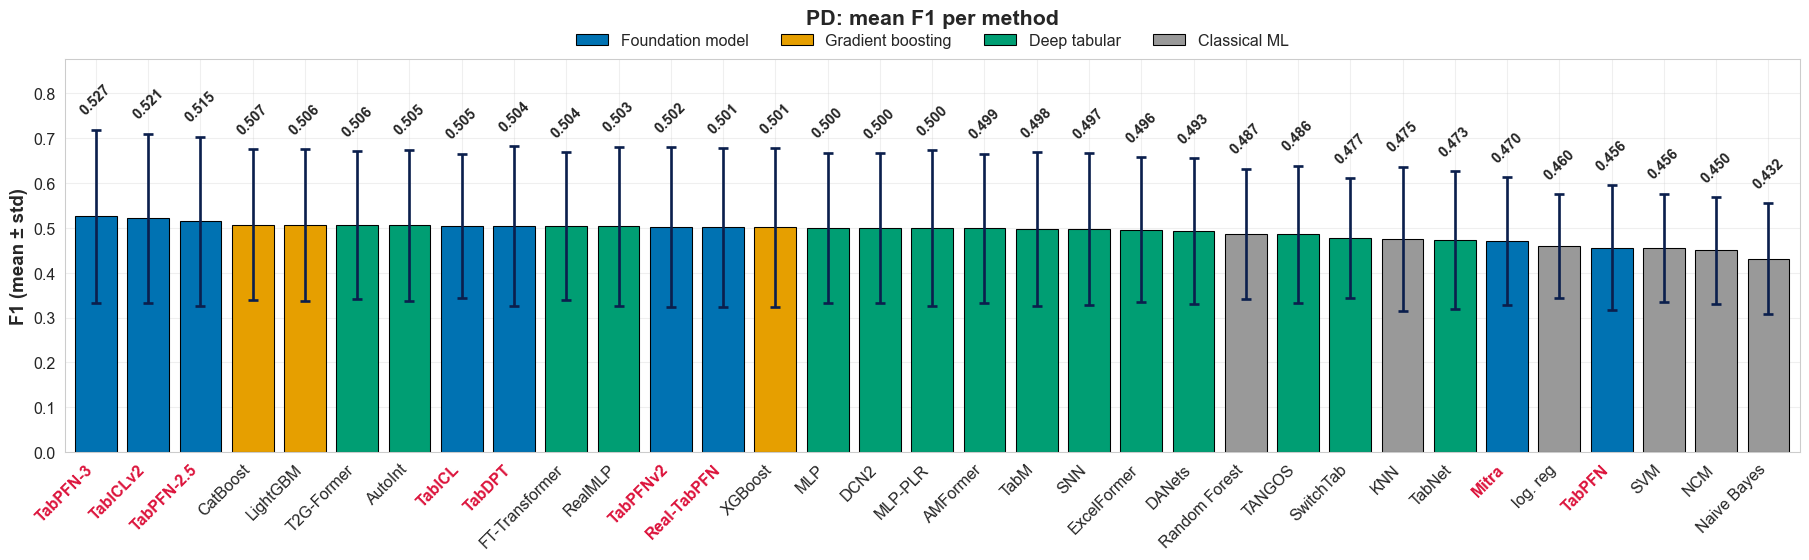

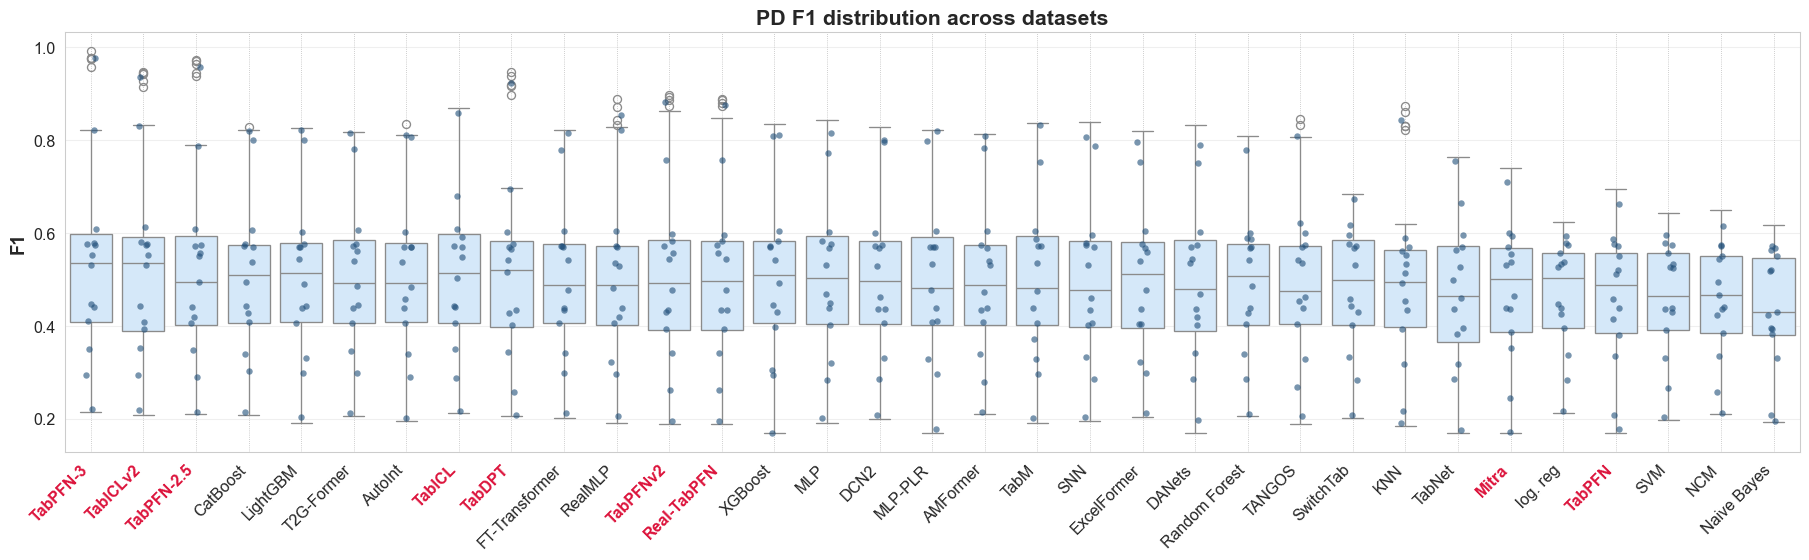

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/pd/pd_box_f1.pdf')

In [6]:
performance_heatmap(df, 'F1', task_name='PD', higher_is_better=True, out_dir=FIGURES_DIR)
metric_bars(df, 'F1', task_name='PD', higher_is_better=True, out_dir=FIGURES_DIR)
metric_boxplots(df, 'F1', task_name='PD', higher_is_better=True, out_dir=FIGURES_DIR)


## 5. Effect of HPO on AUC

Mean HPO-minus-NO_HPO change per method. Foundation models are 0 by design (their HPO run copies NO_HPO).

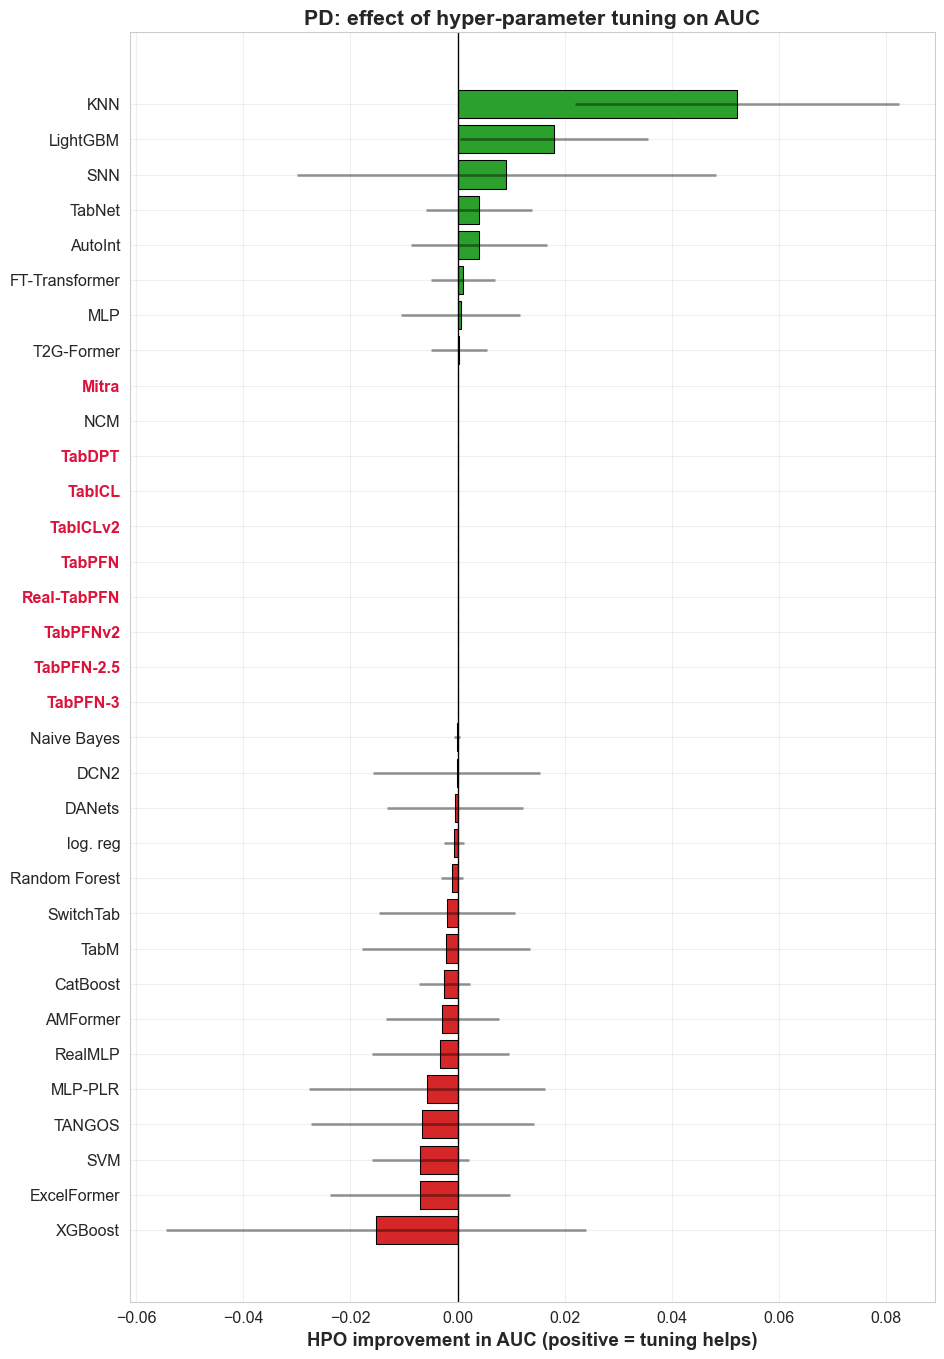

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/pd/pd_hpo_effect_auc.pdf')

In [7]:
hpo_improvement_bars(df_both, 'AUC', task_name='PD', out_dir=FIGURES_DIR)


## 6. Time analysis — train + predict + HPO

For the tunable methods the training time is multiplied by the number of HPO trials (`n_trials`) so the bars reflect the **hyperparameter-search** cost as well as the final fit + predict; in-context foundation models are unchanged. The boxplot shows the raw per-fold compute-time spread, and the scatter is the accuracy-vs-cost frontier (**median** time on x, **mean** AUC on y).

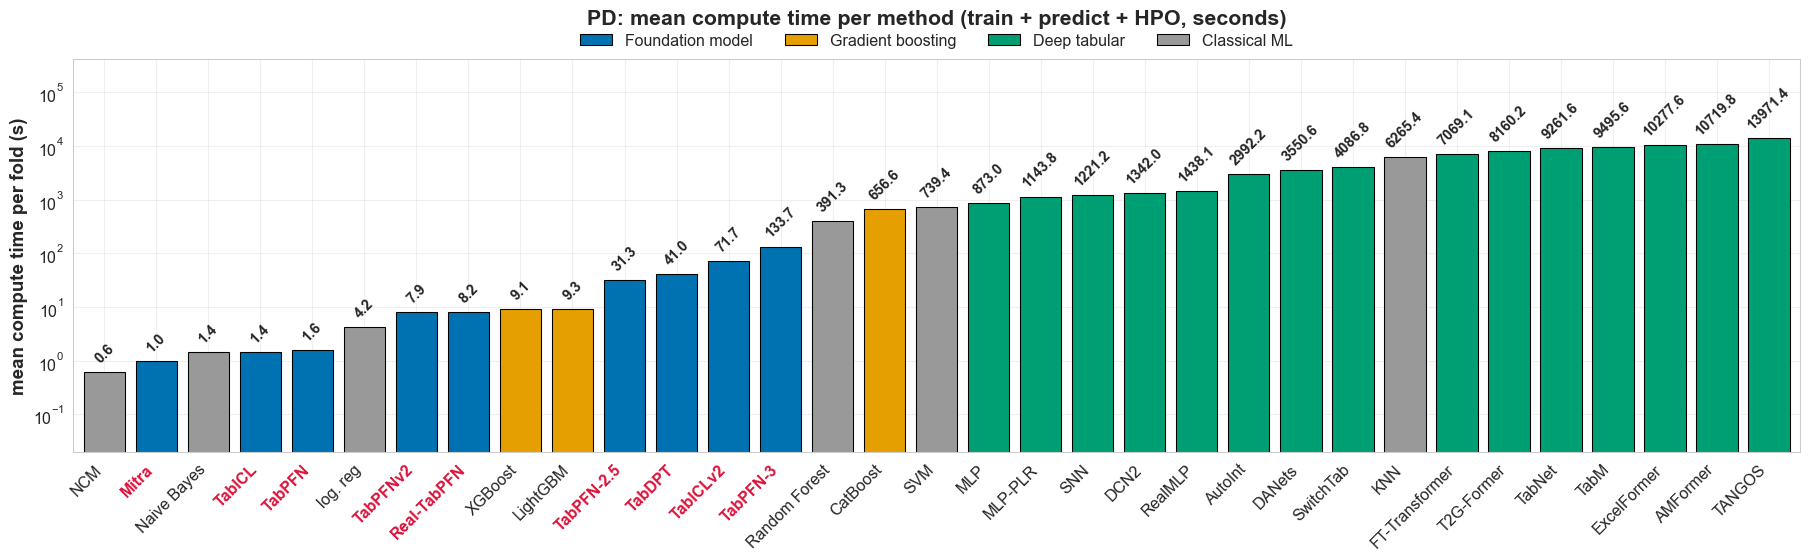

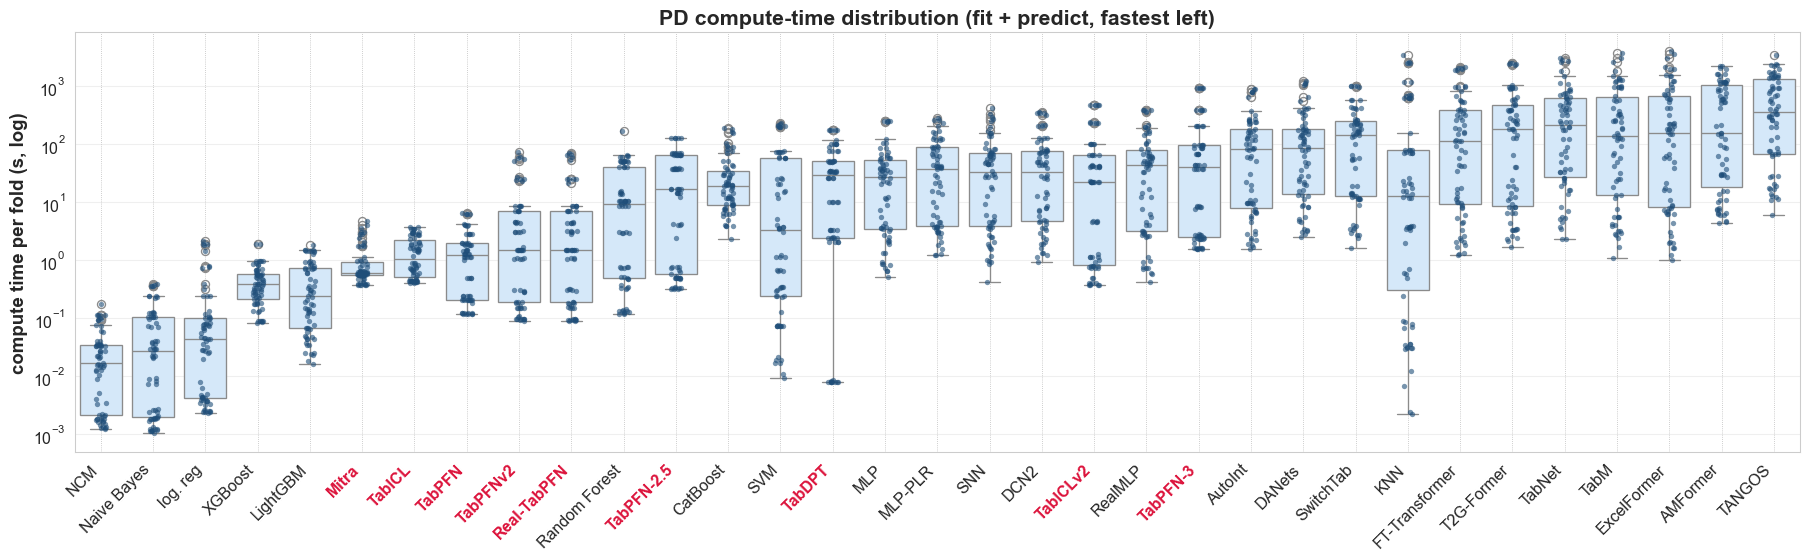

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/pd/pd_box_compute_time.pdf')

In [8]:
compute_time_bars(df, task_name='PD', hpo_methods=HPO_METHODS, n_trials=20, out_dir=FIGURES_DIR)
compute_time_boxplot(df, task_name='PD', out_dir=FIGURES_DIR)


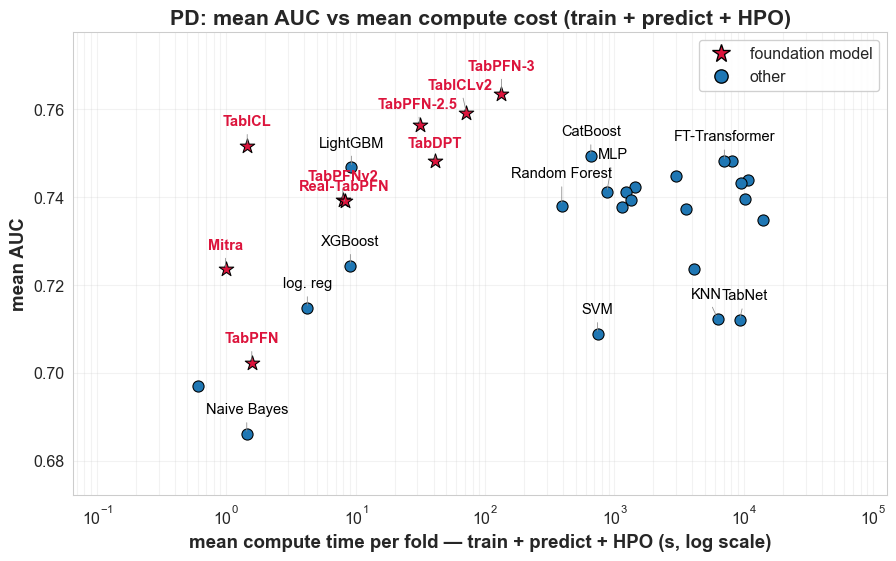

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/pd/pd_cost_quality_auc.pdf')

In [9]:
runtime_performance_scatter(df, 'AUC', task_name='PD', hpo_methods=HPO_METHODS, n_trials=20, out_dir=FIGURES_DIR)


## 7. TabPFN v3 vs the baselines ? head-to-head

The foundation model against the two reference baselines in turn: **CatBoost** (strongest classical learner) and **log. reg** (the regulatory / industry-standard credit baseline). The relative AUC gain over CatBoost is first related to processed dataset rows and immediately afterwards to class imbalance. The corresponding size analysis against logistic regression follows, then the per-dataset AUC scatters with the **y = x** equal-performance diagonal.

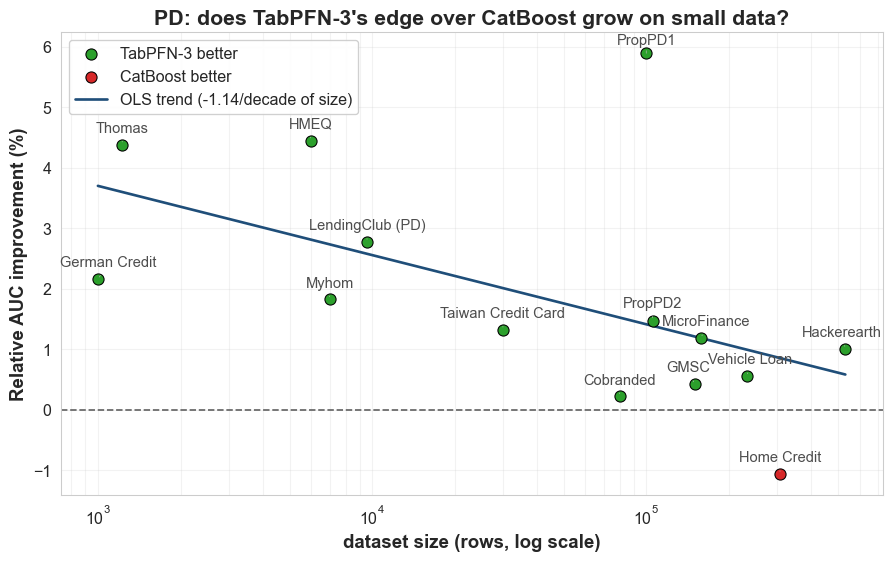

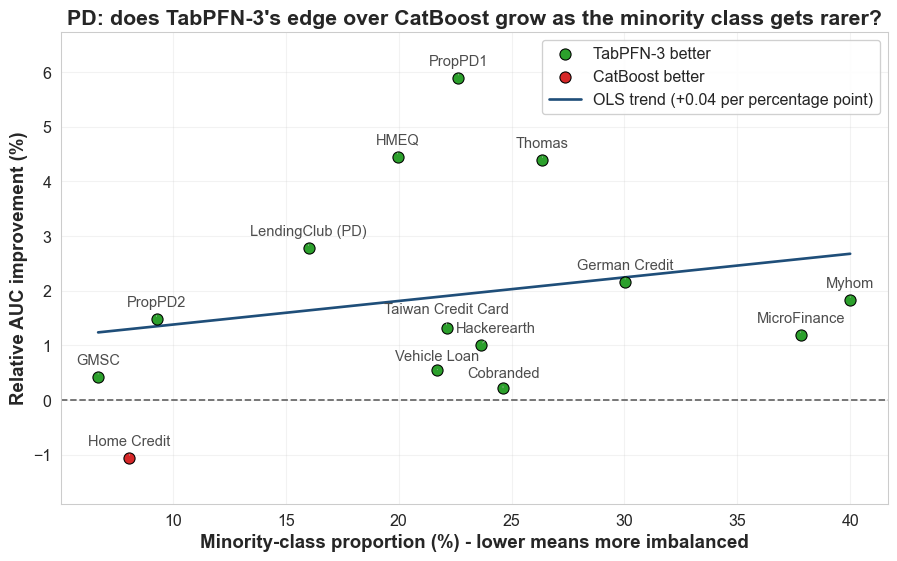

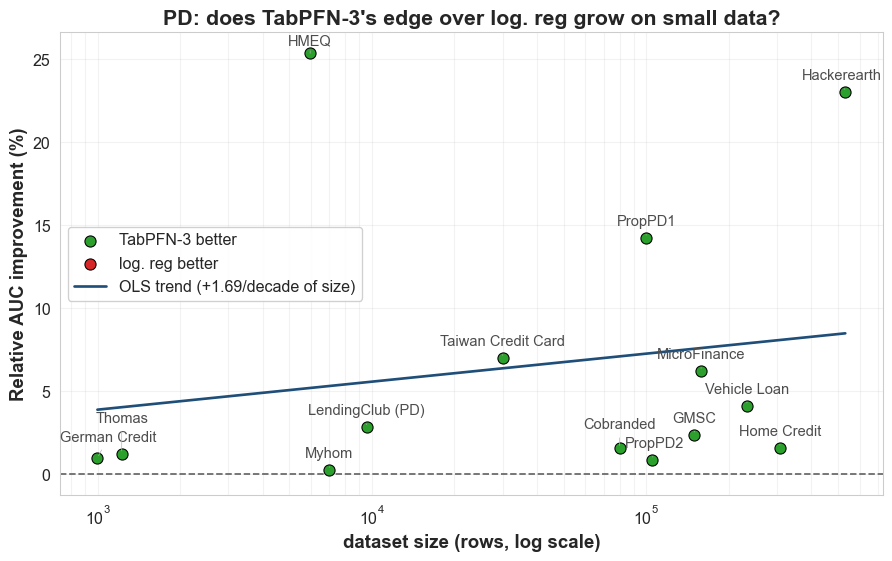

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/pd/pd_tabpfn_v3_vs_LogReg_sizetrend_auc.pdf')

In [10]:
foundation_vs_baseline_size_trend(df, metric='AUC', task='pd', task_name='PD', relative=True, higher_is_better=True, out_dir=FIGURES_DIR)
foundation_vs_baseline_imbalance_trend(
    df, metric='AUC', task_name='PD', relative=True,
    higher_is_better=True, out_dir=FIGURES_DIR
)
foundation_vs_baseline_size_trend(df, metric='AUC', task='pd', task_name='PD', base_method='LogReg', relative=True, higher_is_better=True, out_dir=FIGURES_DIR)


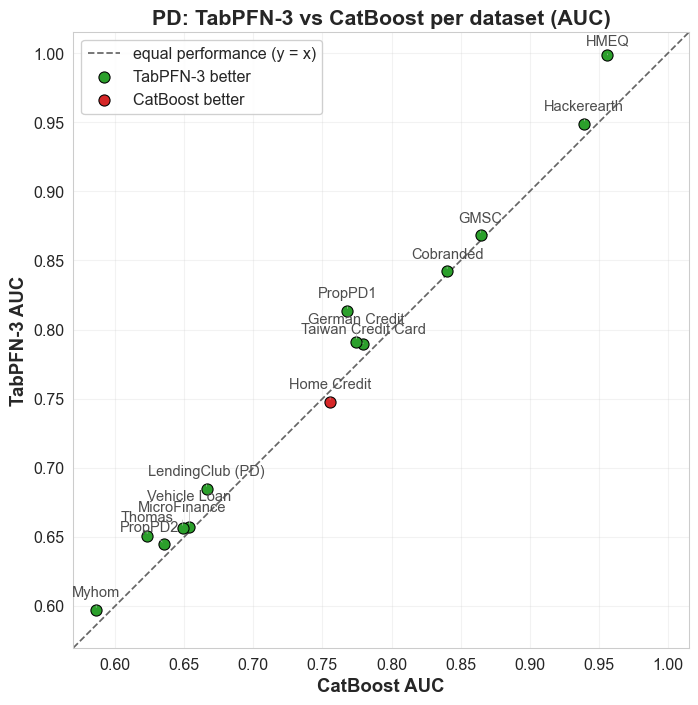

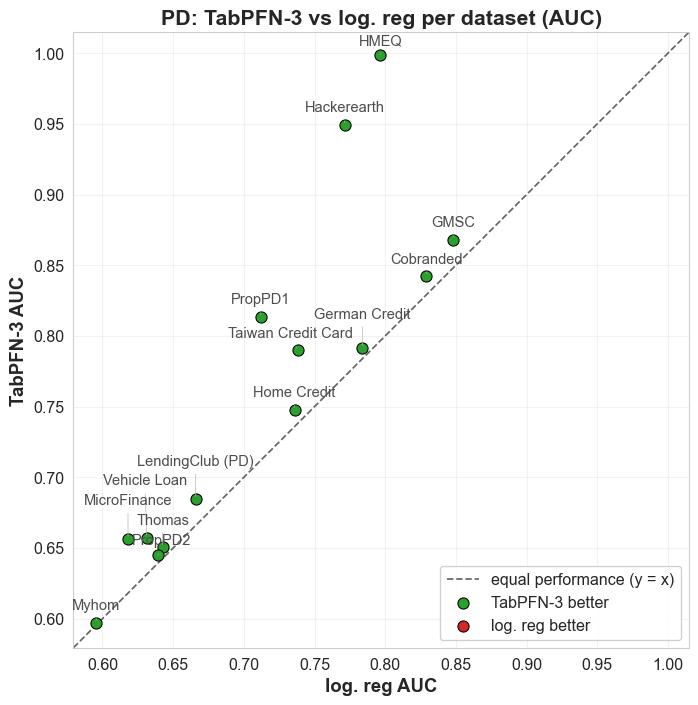

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/pd/pd_tabpfn_v3_vs_LogReg_scatter_auc.pdf')

In [11]:
foundation_vs_baseline_scatter(df, metric='AUC', task_name='PD', higher_is_better=True, out_dir=FIGURES_DIR)
foundation_vs_baseline_scatter(df, metric='AUC', base_method='LogReg', task_name='PD', higher_is_better=True, out_dir=FIGURES_DIR)


## 8. Prediction calibration and systematic bias

Comparison restricted to TabPFN-3, TabICLv2, CatBoost, and log. reg. Three views: the four-panel **observed-versus-predicted summary** (positive observed-minus-predicted values indicate underprediction), the **decile calibration curve** (loans ranked into predicted-PD deciles per dataset; mean observed default rate per decile against the mean prediction, averaged over datasets — the credit-scoring standard reliability view), and the **bias-versus-default-rate scatter**, which shows whether miscalibration concentrates on the rare-default datasets.

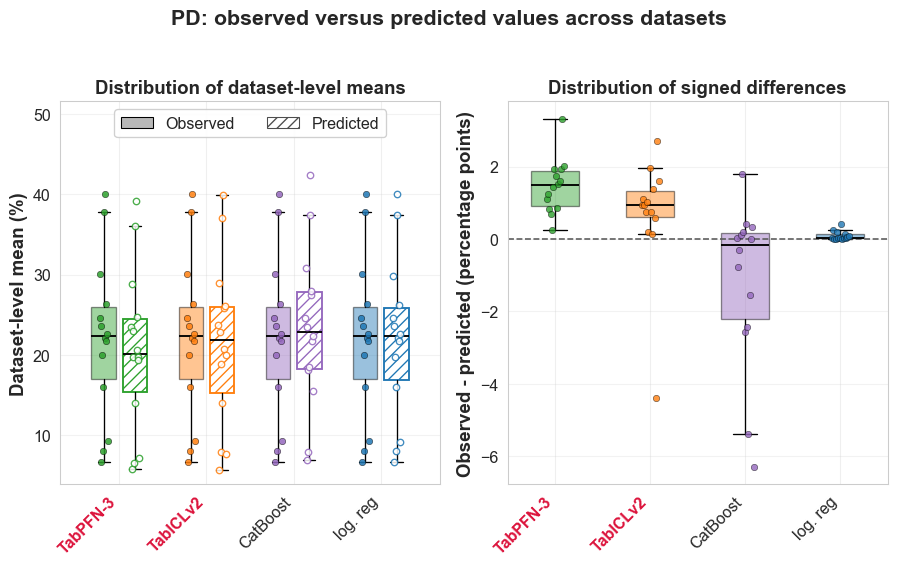

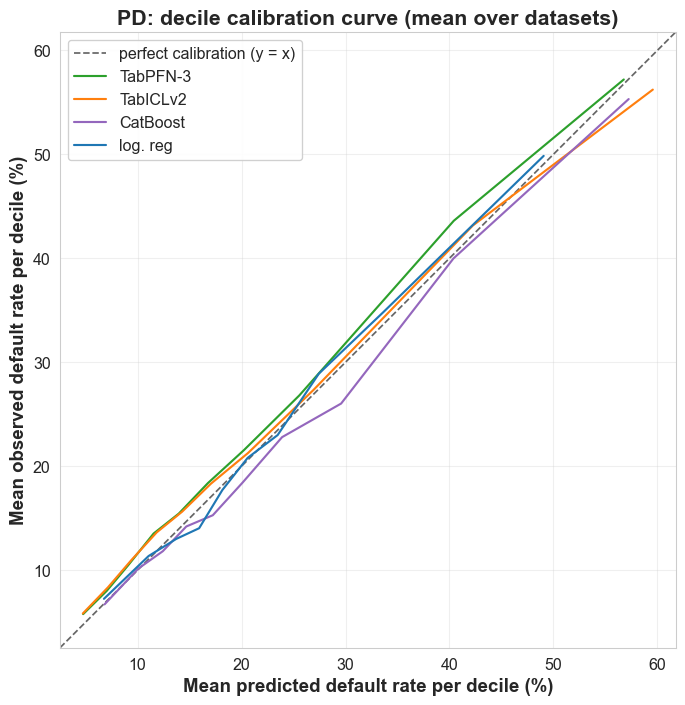

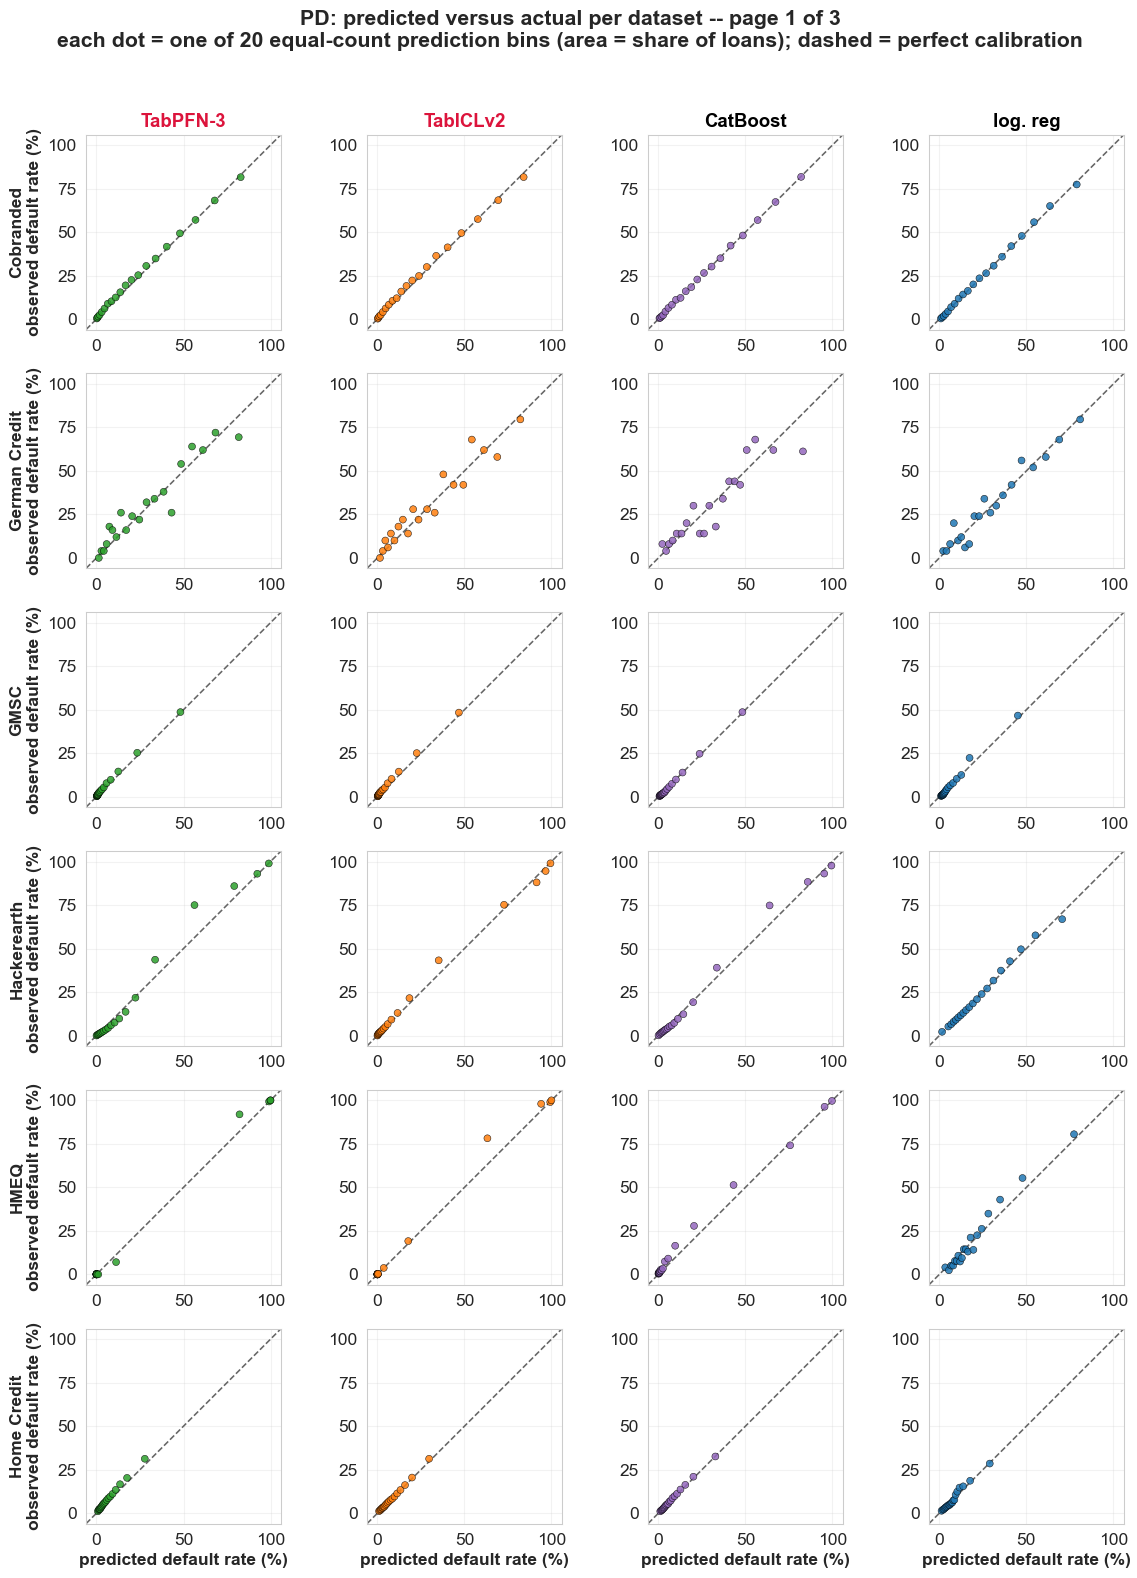

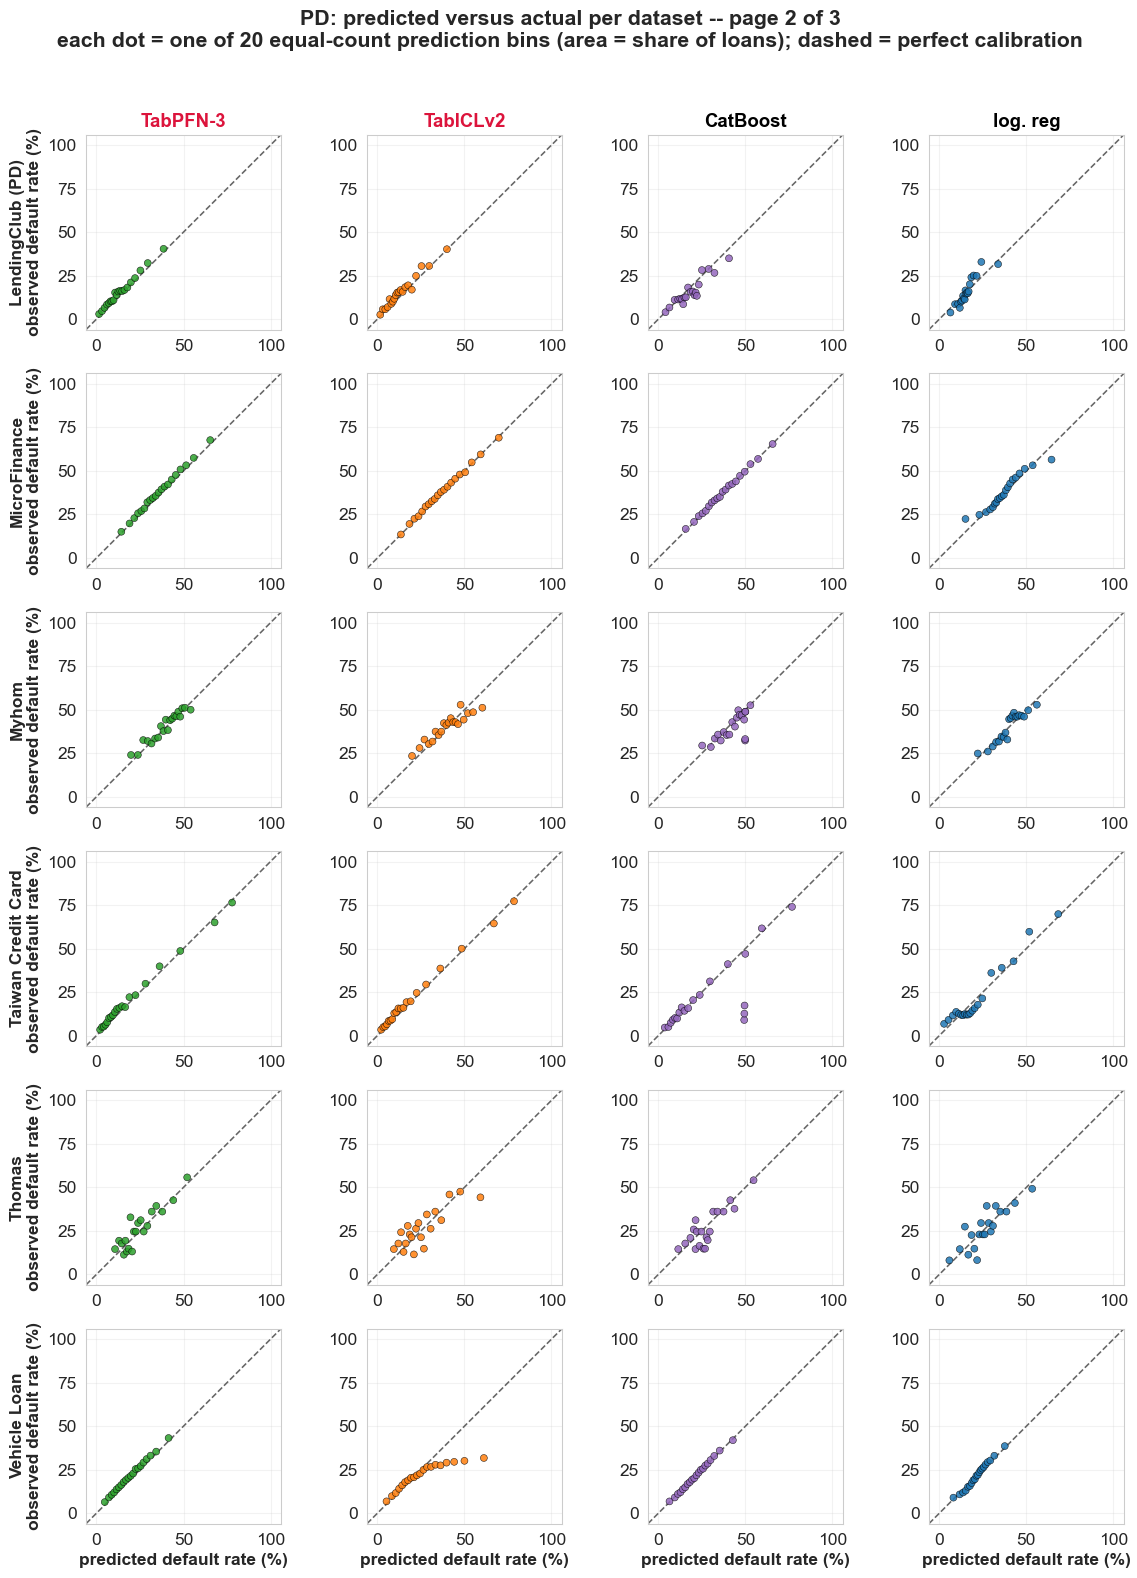

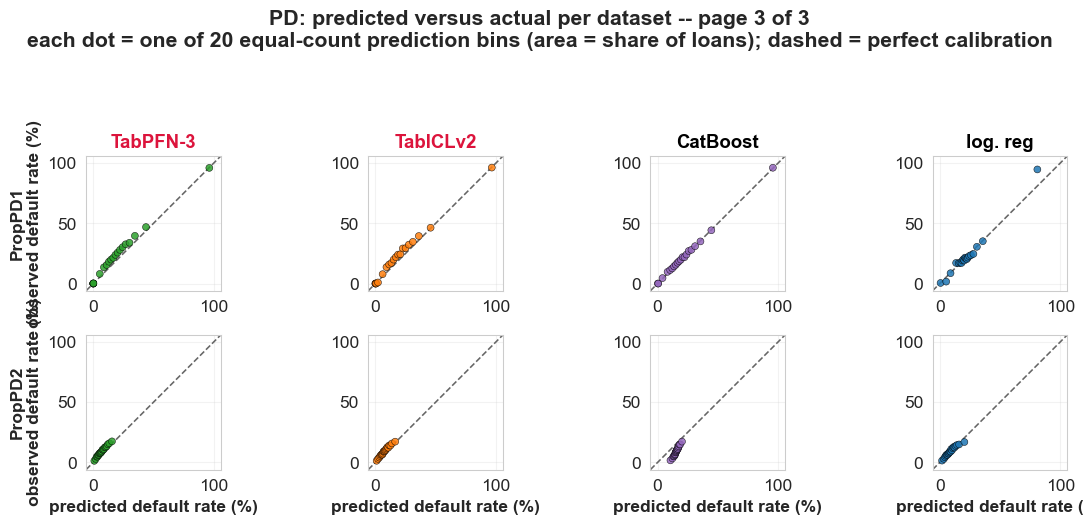

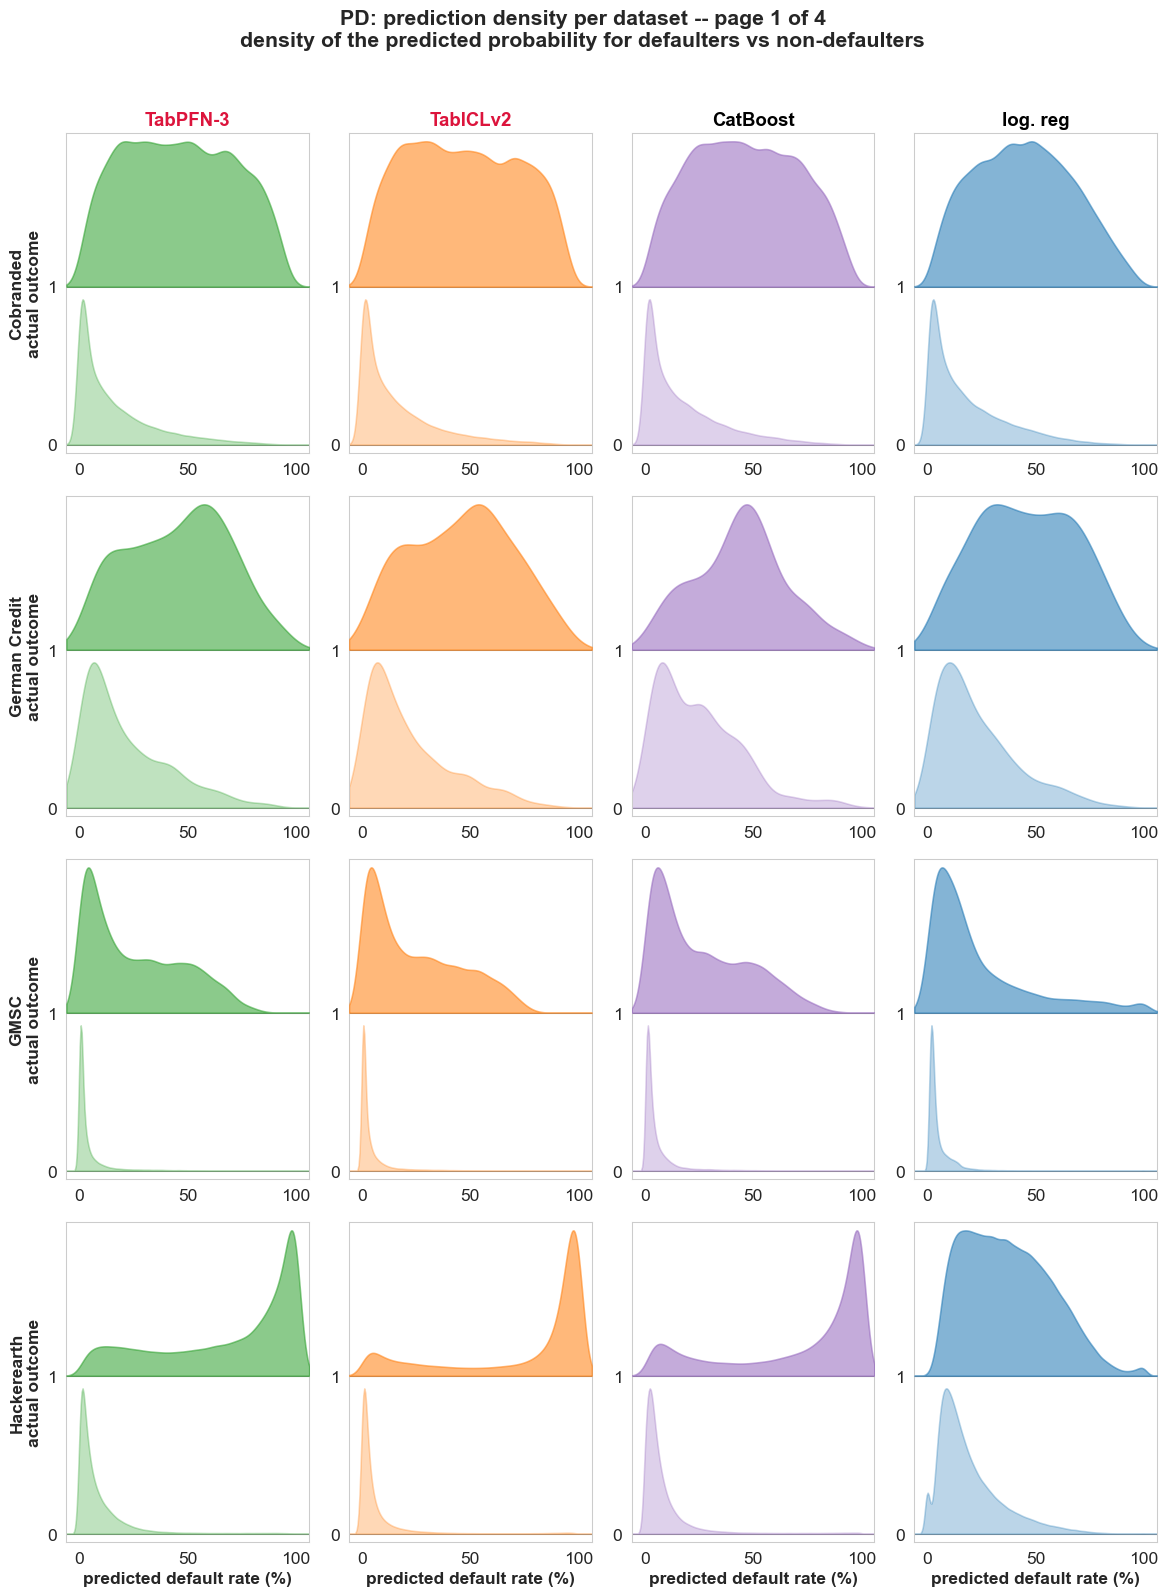

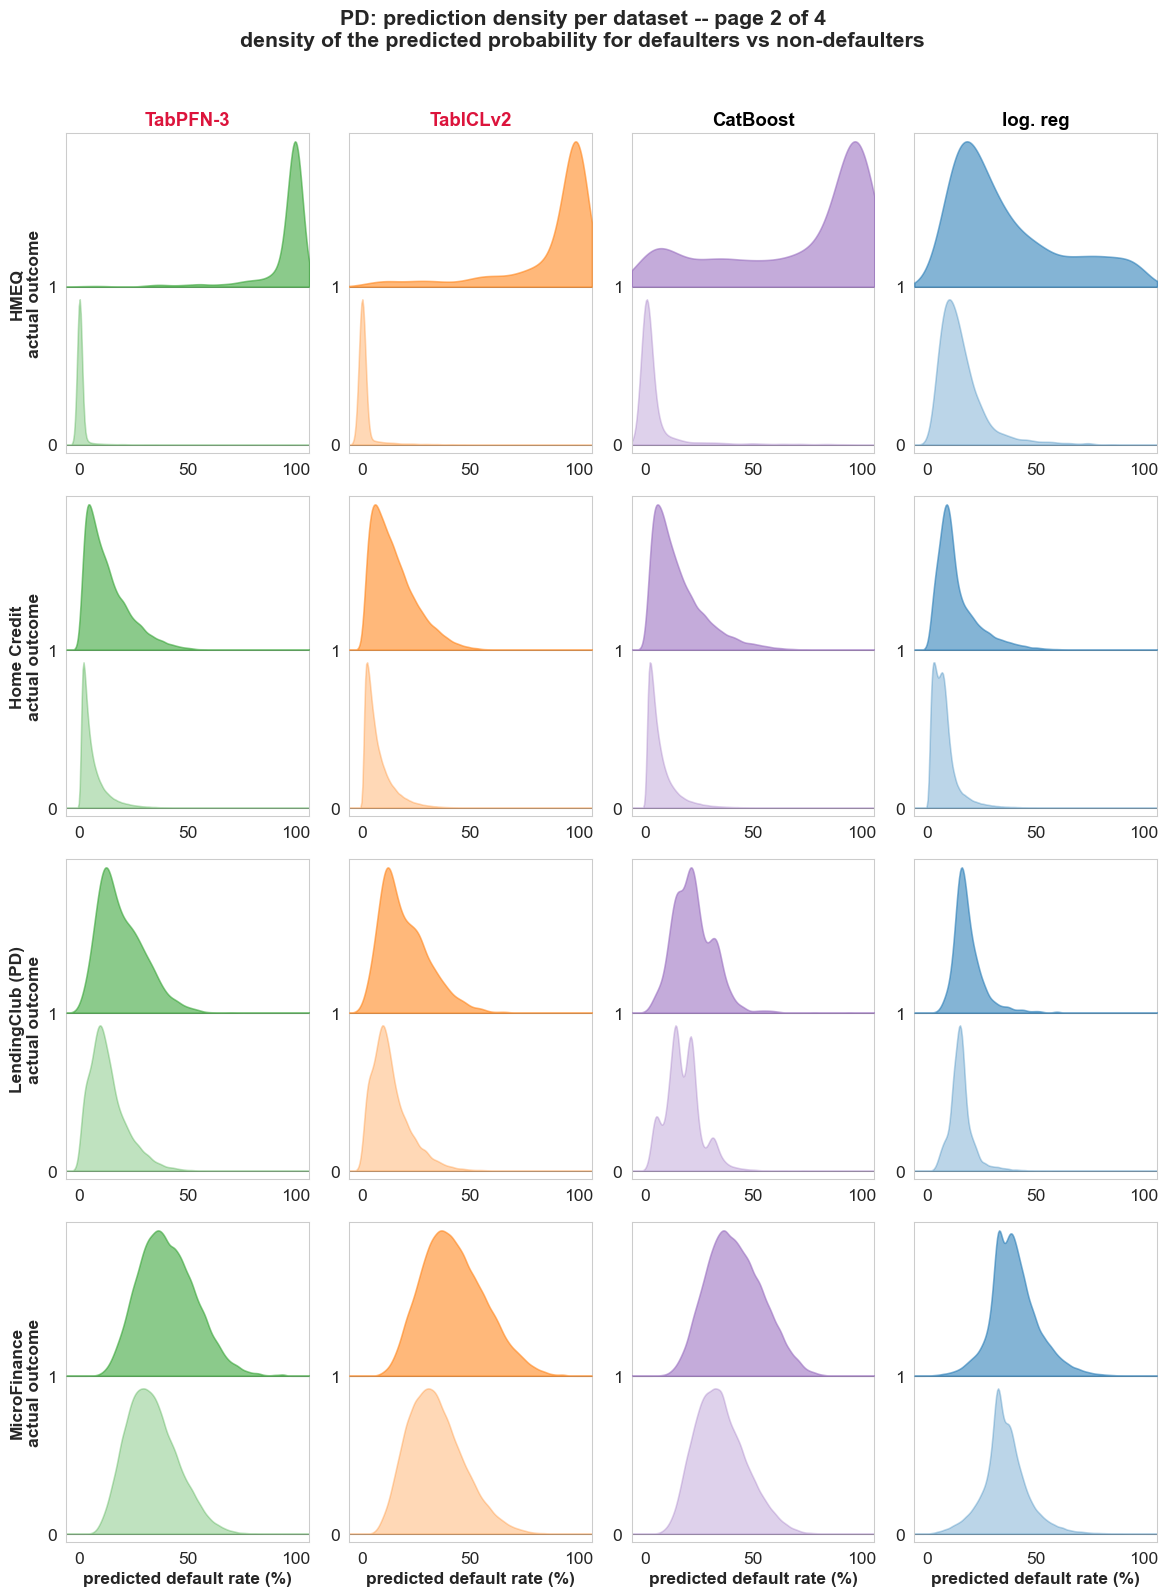

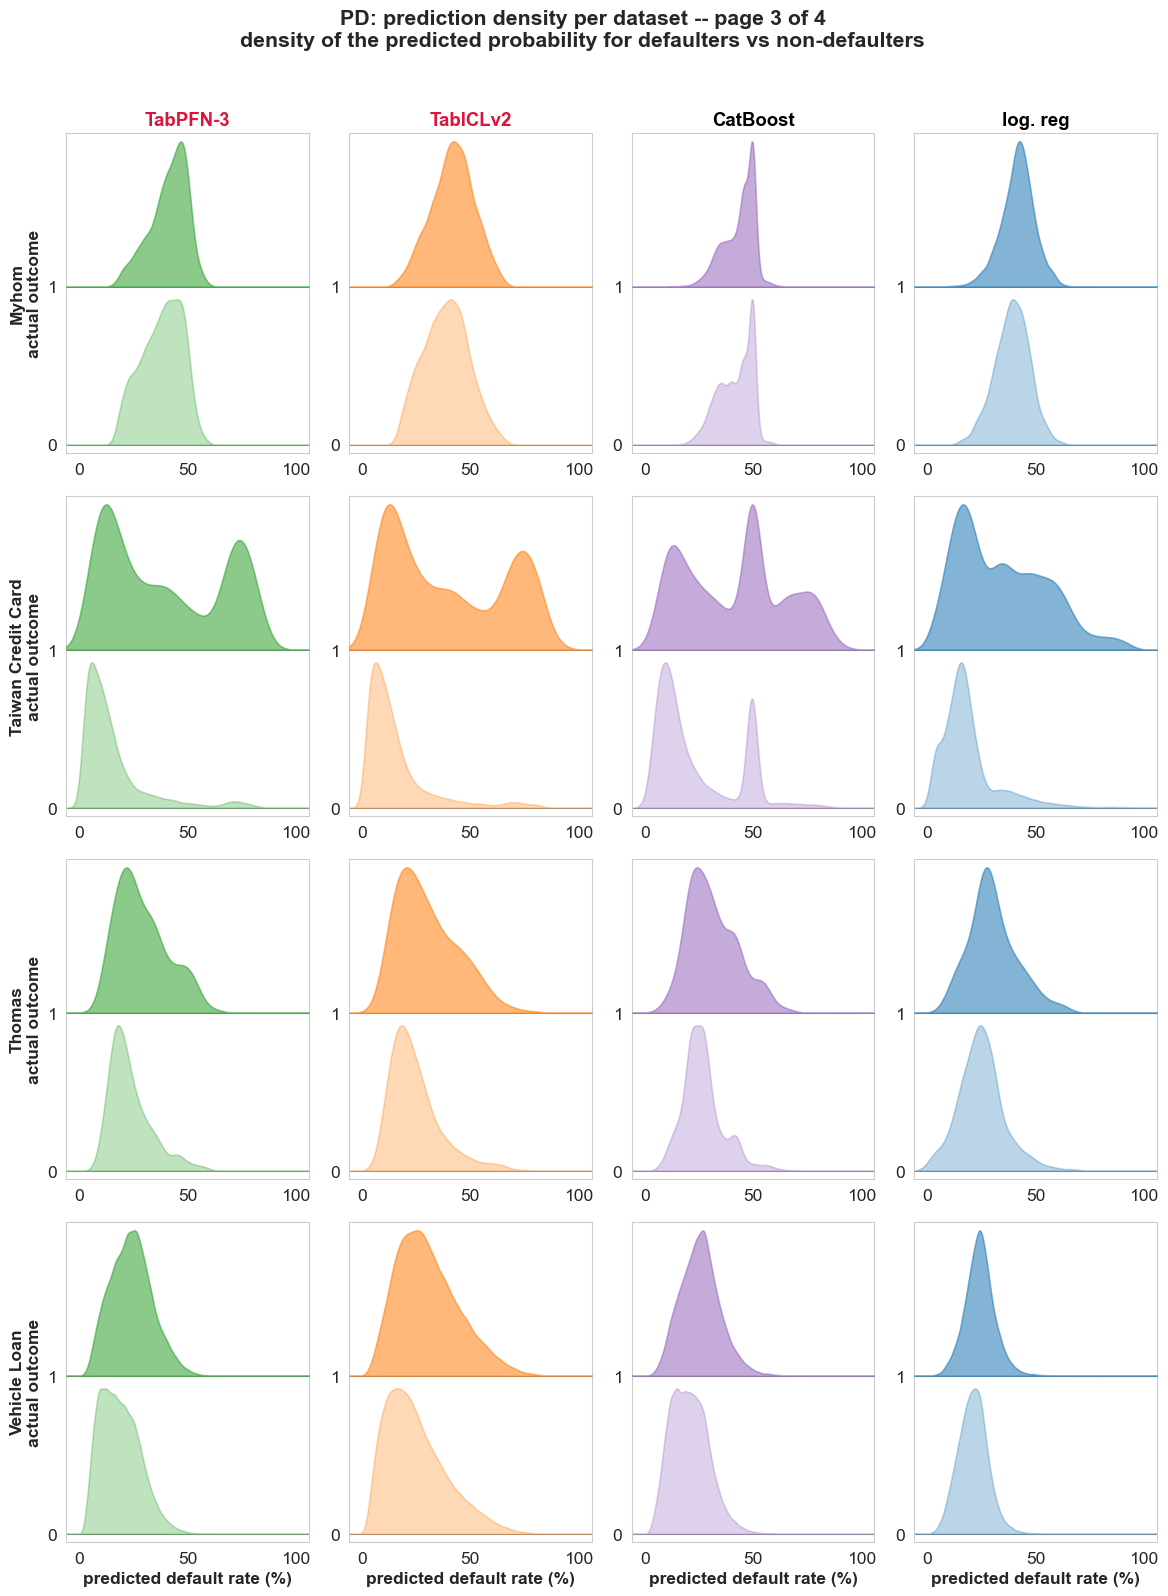

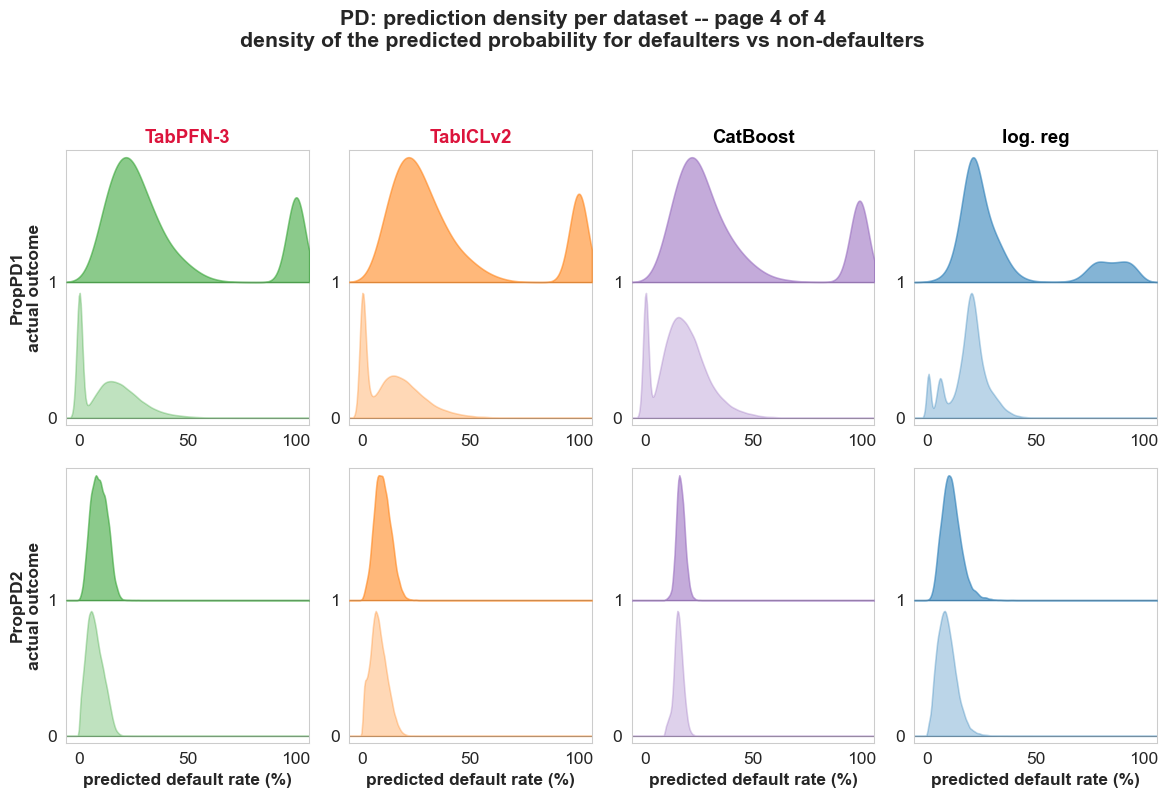

[WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/pd/pd_per_dataset_prediction_density_p1.pdf'),
 WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/pd/pd_per_dataset_prediction_density_p2.pdf'),
 WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/pd/pd_per_dataset_prediction_density_p3.pdf'),
 WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/pd/pd_per_dataset_prediction_density_p4.pdf')]

In [12]:
pd_calibration_methods = ('tabpfn_v3', 'tabicl_v2', 'catboost', 'LogReg')
pd_calibration = calibration_bias_table(
    df, results_root=RESULTS_ROOT, task='pd', methods=pd_calibration_methods
)
selected_method_calibration_summary(
    pd_calibration, task='pd', methods=pd_calibration_methods,
    task_name='PD', out_dir=FIGURES_DIR
)
calibration_decile_curve(
    df, results_root=RESULTS_ROOT, task='pd', methods=pd_calibration_methods,
    task_name='PD', out_dir=FIGURES_DIR
)
per_dataset_calibration_grid(
    df, results_root=RESULTS_ROOT, task='pd', methods=pd_calibration_methods,
    task_name='PD', out_dir=FIGURES_DIR
)
per_dataset_prediction_density(
    df, results_root=RESULTS_ROOT, task='pd', methods=pd_calibration_methods,
    task_name='PD', out_dir=FIGURES_DIR
)


## Summary — the notebook's single printed report

Everything above, in text: this is the notebook's ONLY printed output, so `results/All_Results.md` is a complete text record of the analysis.

In [13]:
notebook_report(
    'Experiment 1 - PD',
    notebook='Experiment1.1-PD.ipynb',
    about=('5-fold CV headline PD benchmark (tuned models): per-method metrics, '
           'ranks, tuning effect, compute time, TabPFN-3 vs the baselines, and the '
           'full prediction-calibration analysis.'),
    sections=[
        section('Coverage',
                f'{df["method"].nunique()} methods x {df["dataset"].nunique()} datasets (HPO runs)'),
        section('Metrics per method (mean over datasets x folds) + compute time',
                capture(pd_summary_text, df, task_name='Experiment 1 - PD')),
        section('Average rank per method (AUC)',
                capture(rank_summary_text, df, 'AUC', task_name='PD')),
        section('Effect of hyper-parameter tuning (AUC)',
                capture(hpo_effect_text, df_both, 'AUC', task_name='PD')),
        section('TabPFN-3 head-to-head per dataset (AUC)',
                capture(head_to_head_text, df, 'AUC', fnd_method='tabpfn_v3',
                        base_methods=('catboost', 'LogReg'), task_name='PD')),
        section('Prediction calibration (every calibration figure, in numbers)',
                capture(calibration_summary_text, pd_calibration, task_name='PD',
                        df=df, results_root=RESULTS_ROOT, task='pd',
                        methods=pd_calibration_methods)),
    ],
)

EXPERIMENT 1 - PD -- COMPLETE TEXT SUMMARY
Source notebook : notebooks/Experiment1.1-PD.ipynb
Contents        : 5-fold CV headline PD benchmark (tuned models): per-method metrics, ranks, tuning effect, compute time, TabPFN-3 vs the baselines, and the full prediction-calibration analysis.
Sections        : 6

This is the notebook's ONLY printed output: every table and figure-backing
number it produces is reproduced below, so results/All_Results.md is a
complete text record of the analysis.

------------------------------------------------------------------------------
[1] Coverage
------------------------------------------------------------------------------
33 methods x 14 datasets (HPO runs)

------------------------------------------------------------------------------
[2] Metrics per method (mean over datasets x folds) + compute time
------------------------------------------------------------------------------
Experiment 1 - PD — mean of every metric per method   (datasets: 14, met

"==============================================================================\nEXPERIMENT 1 - PD -- COMPLETE TEXT SUMMARY\n==============================================================================\nSource notebook : notebooks/Experiment1.1-PD.ipynb\nContents        : 5-fold CV headline PD benchmark (tuned models): per-method metrics, ranks, tuning effect, compute time, TabPFN-3 vs the baselines, and the full prediction-calibration analysis.\nSections        : 6\n\nThis is the notebook's ONLY printed output: every table and figure-backing\nnumber it produces is reproduced below, so results/All_Results.md is a\ncomplete text record of the analysis.\n\n------------------------------------------------------------------------------\n[1] Coverage\n------------------------------------------------------------------------------\n33 methods x 14 datasets (HPO runs)\n\n------------------------------------------------------------------------------\n[2] Metrics per method (mean over datasets